In [1]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

# Download Dataset
import yfinance as yf

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Ignore Warning
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# KONFIGURASI NOTEBOOK
# ==========================================================

pd.set_option("display.max_columns", None)

pd.set_option("display.max_rows", 20)

pd.set_option("display.float_format",
              lambda x: f"{x:.4f}")

plt.style.use("ggplot")

In [3]:
# ==========================================================
# KONFIGURASI PENELITIAN
# ==========================================================

# --------------------------
# Dataset
# --------------------------

TICKER = "AAPL"

START_DATE = "2021-01-01"

END_DATE = "2025-12-31"

# --------------------------
# Split Data
# --------------------------

TEST_SIZE = 0.20

RANDOM_STATE = 42

# --------------------------
# Moving Average
# --------------------------

MA_SHORT = 5

MA_LONG = 20

# --------------------------
# Rolling Window
# --------------------------

RVOL_PERIOD = 20

SR_PERIOD = 20

# --------------------------
# Threshold Rule-Based Labeling
# --------------------------

RVOL_HIGH = 1.20

RETURN_POSITIVE = 0.01

RETURN_NEGATIVE = -0.01

LOW_POSITION = 0.35

HIGH_POSITION = 0.65

TREND_THRESHOLD = 0.01

# --------------------------
# Feature
# --------------------------

FEATURE_COLUMNS = [
    "Return",
    "RVOL",
    "TrendDiff",
    "PricePosition",
    "Breakout",
    "Breakdown"
]

TARGET_COLUMN = "Label"

# --------------------------
# Random Forest
# --------------------------

RF_PARAM_GRID = {

    "n_estimators":[100,200],

    "max_depth":[5,8,None],

    "min_samples_leaf":[1,5],

    "max_features":["sqrt"]

}

# --------------------------
# SVM
# --------------------------

SVM_PARAM_GRID = {

    "C":[0.1,1,10],

    "gamma":[
        "scale",
        0.1,
        0.01
    ],

    "kernel":["rbf"]

}

In [4]:
# ==========================================================
# VALIDASI LIBRARY
# ==========================================================

print("="*60)

print("Library berhasil dimuat")

print("="*60)

print("Pandas :", pd.__version__)

print("NumPy :", np.__version__)

print("Yahoo Finance siap digunakan")

print("="*60)

Library berhasil dimuat
Pandas : 3.0.3
NumPy : 2.5.1
Yahoo Finance siap digunakan


In [5]:
# ==========================================================
# RINGKASAN KONFIGURASI
# ==========================================================

print("===== KONFIGURASI PENELITIAN =====")

print(f"Ticker                 : {TICKER}")

print(f"Periode                : {START_DATE} s.d. {END_DATE}")

print(f"Train Test Split       : {int((1-TEST_SIZE)*100)}% : {int(TEST_SIZE*100)}%")

print(f"Moving Average         : MA{MA_SHORT} & MA{MA_LONG}")

print(f"RVOL Period            : {RVOL_PERIOD}")

print(f"Support Resistance     : {SR_PERIOD}")

print(f"Random State           : {RANDOM_STATE}")

===== KONFIGURASI PENELITIAN =====
Ticker                 : AAPL
Periode                : 2021-01-01 s.d. 2025-12-31
Train Test Split       : 80% : 20%
Moving Average         : MA5 & MA20
RVOL Period            : 20
Support Resistance     : 20
Random State           : 42


## 2. Pengumpulan Data

Tahap pengumpulan data dilakukan dengan mengambil data historis saham melalui Yahoo Finance menggunakan pustaka `yfinance`. Data yang digunakan berupa data harian saham Bank Central Asia Tbk dengan kode ticker BBCA.JK pada periode 1 Januari 2021 sampai 31 Desember 2025.

Atribut yang dikumpulkan meliputi:

- Date
- Open
- High
- Low
- Close
- Volume

In [6]:
# ==========================================================
# PENGUMPULAN DATA DARI YAHOO FINANCE
# ==========================================================

df_raw = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=False,
    progress=False
)

if df_raw.empty:
    raise ValueError(
        f"Data untuk ticker {TICKER} tidak ditemukan."
    )

print("Data berhasil diunduh.")
print("Jumlah baris awal:", len(df_raw))

Data berhasil diunduh.
Jumlah baris awal: 1254


In [7]:
# ==========================================================
# MENANGANI MULTIINDEX DARI YFINANCE
# ==========================================================

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

print(df_raw.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [8]:
# ==========================================================
# MENGUBAH INDEX DATE MENJADI KOLOM
# ==========================================================

df_raw = df_raw.reset_index()

df_raw.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-01-04,125.7409,129.4100,133.6100,126.7600,133.5200,143301900
1,2021-01-05,127.2955,131.0100,131.7400,128.4300,128.8900,97664900
2,2021-01-06,123.0105,126.6000,131.0500,126.3800,127.7200,155088000
3,2021-01-07,127.2080,130.9200,131.6300,127.8600,128.3600,109578200
4,2021-01-08,128.3060,132.0500,132.6300,130.2300,132.4300,105158200


In [9]:
# ==========================================================
# MEMILIH KOLOM YANG DIGUNAKAN
# ==========================================================

required_columns = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

missing_columns = [
    col for col in required_columns
    if col not in df_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Kolom berikut tidak tersedia: {missing_columns}"
    )

df = df_raw[required_columns].copy()

df.head()

Price,Date,Open,High,Low,Close,Volume
0,2021-01-04,133.5200,133.6100,126.7600,129.4100,143301900
1,2021-01-05,128.8900,131.7400,128.4300,131.0100,97664900
2,2021-01-06,127.7200,131.0500,126.3800,126.6000,155088000
3,2021-01-07,128.3600,131.6300,127.8600,130.9200,109578200
4,2021-01-08,132.4300,132.6300,130.2300,132.0500,105158200


In [10]:
# ==========================================================
# KONVERSI TIPE DATA
# ==========================================================

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

print(df.dtypes)

Price
Date      datetime64[s]
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
dtype: object


In [11]:
# ==========================================================
# MENGURUTKAN DATA SECARA KRONOLOGIS
# ==========================================================

df = (
    df.sort_values("Date")
      .reset_index(drop=True)
)

df.head()

Price,Date,Open,High,Low,Close,Volume
0,2021-01-04,133.5200,133.6100,126.7600,129.4100,143301900
1,2021-01-05,128.8900,131.7400,128.4300,131.0100,97664900
2,2021-01-06,127.7200,131.0500,126.3800,126.6000,155088000
3,2021-01-07,128.3600,131.6300,127.8600,130.9200,109578200
4,2021-01-08,132.4300,132.6300,130.2300,132.0500,105158200


In [12]:
# ==========================================================
# INFORMASI DATASET AWAL
# ==========================================================

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)

print(f"Ticker             : {TICKER}")
print(f"Jumlah data        : {len(df)}")
print(f"Jumlah kolom       : {df.shape[1]}")
print(f"Tanggal awal       : {df['Date'].min()}")
print(f"Tanggal akhir      : {df['Date'].max()}")

print("=" * 60)

df.info()

INFORMASI DATASET
Ticker             : AAPL
Jumlah data        : 1254
Jumlah kolom       : 6
Tanggal awal       : 2021-01-04 00:00:00
Tanggal akhir      : 2025-12-30 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 1254 entries, 0 to 1253
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    1254 non-null   datetime64[s]
 1   Open    1254 non-null   float64      
 2   High    1254 non-null   float64      
 3   Low     1254 non-null   float64      
 4   Close   1254 non-null   float64      
 5   Volume  1254 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 58.9 KB


In [13]:
# ==========================================================
# MENAMPILKAN DATASET AWAL
# ==========================================================

display(df.head(10))

Price,Date,Open,High,Low,Close,Volume
0,2021-01-04,133.5200,133.6100,126.7600,129.4100,143301900
1,2021-01-05,128.8900,131.7400,128.4300,131.0100,97664900
2,2021-01-06,127.7200,131.0500,126.3800,126.6000,155088000
3,2021-01-07,128.3600,131.6300,127.8600,130.9200,109578200
4,2021-01-08,132.4300,132.6300,130.2300,132.0500,105158200
5,2021-01-11,129.1900,130.1700,128.5000,128.9800,100384500
6,2021-01-12,128.5000,129.6900,126.8600,128.8000,91951100
7,2021-01-13,128.7600,131.4500,128.4900,130.8900,88636800
8,2021-01-14,130.8000,131.0000,128.7600,128.9100,90221800
9,2021-01-15,128.7800,130.2200,127.0000,127.1400,111598500


In [14]:
# ==========================================================
# VALIDASI DATASET AWAL
# ==========================================================

assert not df.empty, "Dataset kosong."
assert set(required_columns).issubset(df.columns), (
    "Kolom OHLCV belum lengkap."
)
assert pd.api.types.is_datetime64_any_dtype(df["Date"]), (
    "Kolom Date belum bertipe datetime."
)

for col in numeric_columns:
    assert pd.api.types.is_numeric_dtype(df[col]), (
        f"Kolom {col} belum bertipe numerik."
    )

print("Validasi dataset awal berhasil.")

Validasi dataset awal berhasil.


In [15]:
# ==========================================================
# RINGKASAN PENGUMPULAN DATA
# ==========================================================

collection_summary = pd.DataFrame({
    "Informasi": [
        "Ticker",
        "Sumber Data",
        "Frekuensi",
        "Tanggal Awal",
        "Tanggal Akhir",
        "Jumlah Data",
        "Jumlah Variabel"
    ],
    "Nilai": [
        TICKER,
        "Yahoo Finance",
        "Harian",
        df["Date"].min().date(),
        df["Date"].max().date(),
        len(df),
        len(required_columns)
    ]
})

display(collection_summary)

,Informasi,Nilai
0,Ticker,AAPL
1,Sumber Data,Yahoo Finance
2,Frekuensi,Harian
3,Tanggal Awal,2021-01-04
4,Tanggal Akhir,2025-12-30
5,Jumlah Data,1254
6,Jumlah Variabel,6


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) bertujuan untuk memahami karakteristik dataset sebelum dilakukan proses pra-pemrosesan data. Tahap ini meliputi pemeriksaan statistik deskriptif, kualitas data, identifikasi outlier, serta visualisasi harga dan volume transaksi saham.

Tahap EDA tidak melakukan perubahan terhadap dataset, melainkan hanya melakukan analisis untuk memperoleh gambaran awal mengenai data penelitian.

In [16]:
# ==========================================================
# 3.1 INFORMASI DATASET
# ==========================================================

print("="*60)
print("INFORMASI DATASET")
print("="*60)

print(f"Jumlah Data     : {len(df)}")
print(f"Jumlah Kolom    : {df.shape[1]}")
print(f"Periode Data    : {df['Date'].min().date()} s.d. {df['Date'].max().date()}")

print("\nTipe Data")
display(df.dtypes)

INFORMASI DATASET
Jumlah Data     : 1254
Jumlah Kolom    : 6
Periode Data    : 2021-01-04 s.d. 2025-12-30

Tipe Data


Price
Date      datetime64[s]
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
dtype: object

In [17]:
# ==========================================================
# 3.2 STATISTIK DESKRIPTIF
# ==========================================================

descriptive = df.describe().T

display(descriptive)

,count,mean,min,25%,50%,75%,max,std
Price,,,,,,,,
Date,1254,2023-07-01 14:52:14,2021-01-04 00:00:00,2022-03-31 06:00:00,2023-07-01 12:00:00,2024-09-29 06:00:00,2025-12-30 00:00:00,NaN
Open,1254.0000,181.2657,119.0300,148.8625,173.8650,210.5700,286.2000,39.1262
High,1254.0000,183.2338,120.4000,150.3250,175.7500,213.4600,288.6200,39.3903
Low,1254.0000,179.4797,116.2100,147.4525,172.1600,208.7600,283.3000,38.9015
Close,1254.0000,181.4468,116.3600,148.9750,174.2600,211.1550,286.1900,39.1765
Volume,1254.0000,69849407.4960,17910600.0000,48395150.0000,63138550.0000,84551325.0000,318679900.0000,29950813.7598


In [18]:
# ==========================================================
# 3.3 MISSING VALUE
# ==========================================================

missing = pd.DataFrame({
    "Jumlah Missing": df.isnull().sum(),
    "Persentase (%)": round(df.isnull().mean()*100,2)
})

display(missing)

print(f"Total Missing Value : {df.isnull().sum().sum()}")

,Jumlah Missing,Persentase (%)
Price,,
Date,0,0.0000
Open,0,0.0000
High,0,0.0000
Low,0,0.0000
Close,0,0.0000
Volume,0,0.0000


Total Missing Value : 0


In [19]:
# ==========================================================
# 3.4 DATA DUPLIKAT
# ==========================================================

duplicate = df.duplicated().sum()

print(f"Jumlah Data Duplikat : {duplicate}")

if duplicate > 0:
    display(df[df.duplicated()])

Jumlah Data Duplikat : 0


In [20]:
# ==========================================================
# 3.5.1 PEMERIKSAAN OUTLIER (IQR)
# ==========================================================

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

outlier_summary = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    total = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "Variabel": col,
        "Q1": round(Q1,2),
        "Q3": round(Q3,2),
        "Lower Bound": round(lower,2),
        "Upper Bound": round(upper,2),
        "Jumlah Outlier": total
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Variabel,Q1,Q3,Lower Bound,Upper Bound,Jumlah Outlier
0,Open,148.8600,210.5700,56.3000,303.1300,0
1,High,150.3300,213.4600,55.6200,308.1600,0
2,Low,147.4500,208.7600,55.4900,300.7200,0
3,Close,148.9800,211.1600,55.7100,304.4300,0
4,Volume,48395150.0000,84551325.0000,-5839112.5000,138785587.5000,42


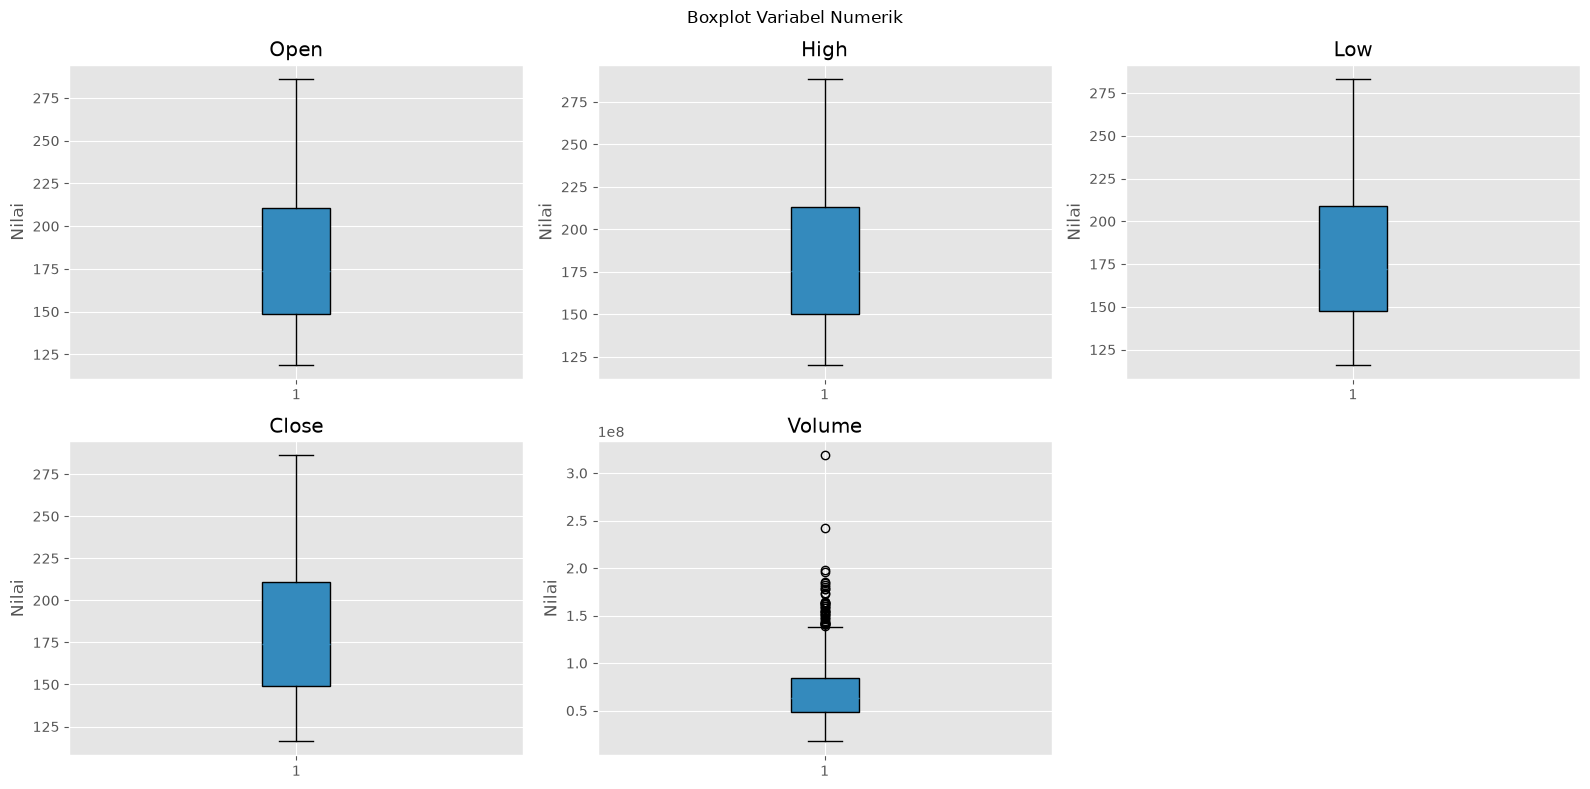

In [21]:
# ==========================================================
# 3.5.2 BOXPLOT OUTLIER
# ==========================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes = axes.flatten()

for i, col in enumerate(numeric_columns):

    axes[i].boxplot(
        df[col],
        vert=True,
        patch_artist=True
    )

    axes[i].set_title(col)
    axes[i].set_ylabel("Nilai")

# Menghapus subplot kosong
fig.delaxes(axes[5])

plt.suptitle("Boxplot Variabel Numerik")

plt.tight_layout()

plt.show()

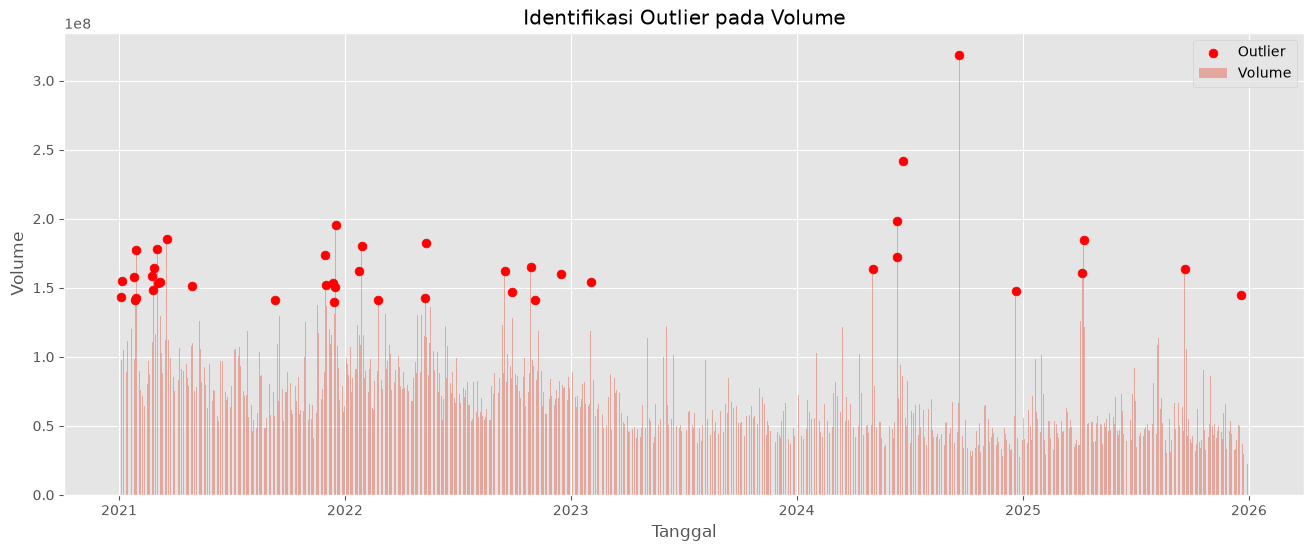

In [22]:
# ==========================================================
# 3.5.3 VISUALISASI OUTLIER VOLUME
# ==========================================================

Q1 = df["Volume"].quantile(0.25)
Q3 = df["Volume"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier = (
    (df["Volume"] < lower) |
    (df["Volume"] > upper)
)

plt.figure(figsize=(16,6))

plt.bar(
    df["Date"],
    df["Volume"],
    alpha=0.4,
    label="Volume"
)

plt.scatter(
    df.loc[outlier, "Date"],
    df.loc[outlier, "Volume"],
    color="red",
    s=40,
    label="Outlier"
)

plt.title("Identifikasi Outlier pada Volume")

plt.xlabel("Tanggal")

plt.ylabel("Volume")

plt.legend()

plt.show()

In [23]:
# ==========================================================
# 3.5.5 KESIMPULAN OUTLIER
# ==========================================================

print("="*60)
print("KESIMPULAN PEMERIKSAAN OUTLIER")
print("="*60)

display(outlier_summary)

print("\nCatatan:")
print("- Outlier diidentifikasi menggunakan metode Interquartile Range (IQR).")
print("- Outlier tidak dihapus pada tahap EDA.")
print("- Penelitian ini mempertahankan outlier karena pada data saham lonjakan harga maupun volume sering kali merupakan peristiwa pasar yang valid, seperti aksi korporasi atau rilis laporan keuangan.")

KESIMPULAN PEMERIKSAAN OUTLIER


,Variabel,Q1,Q3,Lower Bound,Upper Bound,Jumlah Outlier
0,Open,148.8600,210.5700,56.3000,303.1300,0
1,High,150.3300,213.4600,55.6200,308.1600,0
2,Low,147.4500,208.7600,55.4900,300.7200,0
3,Close,148.9800,211.1600,55.7100,304.4300,0
4,Volume,48395150.0000,84551325.0000,-5839112.5000,138785587.5000,42



Catatan:
- Outlier diidentifikasi menggunakan metode Interquartile Range (IQR).
- Outlier tidak dihapus pada tahap EDA.
- Penelitian ini mempertahankan outlier karena pada data saham lonjakan harga maupun volume sering kali merupakan peristiwa pasar yang valid, seperti aksi korporasi atau rilis laporan keuangan.


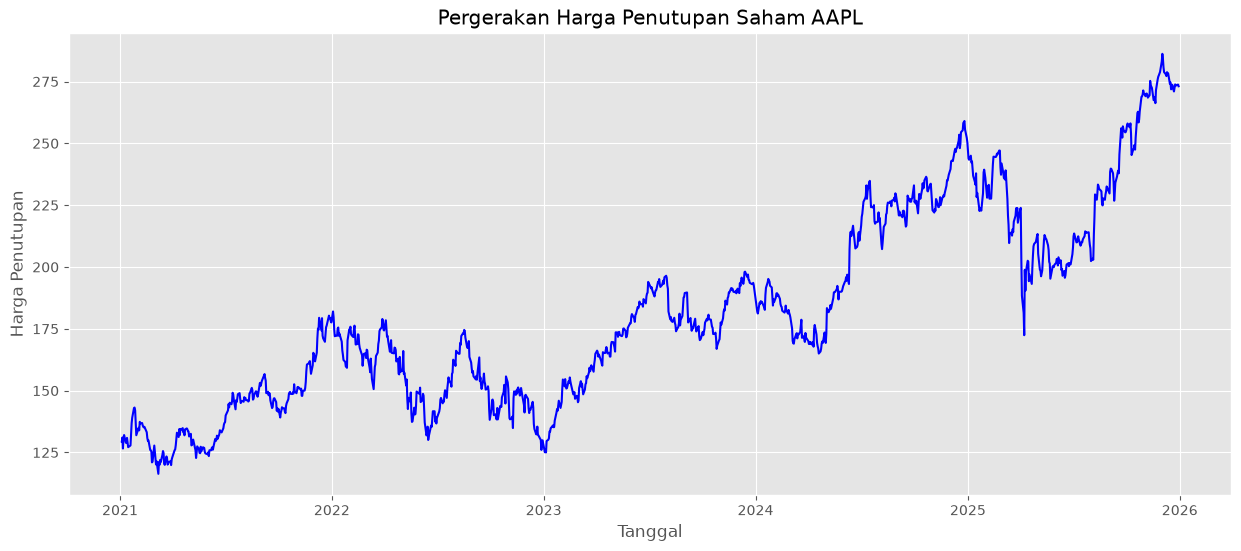

In [24]:
# ==========================================================
# 3.6 VISUALISASI HARGA
# ==========================================================

plt.figure(figsize=(15,6))

plt.plot(
    df["Date"],
    df["Close"],
    linewidth=1.5,
    color="blue"
)

plt.title("Pergerakan Harga Penutupan Saham " + TICKER)

plt.xlabel("Tanggal")

plt.ylabel("Harga Penutupan")

plt.grid(True)

plt.show()

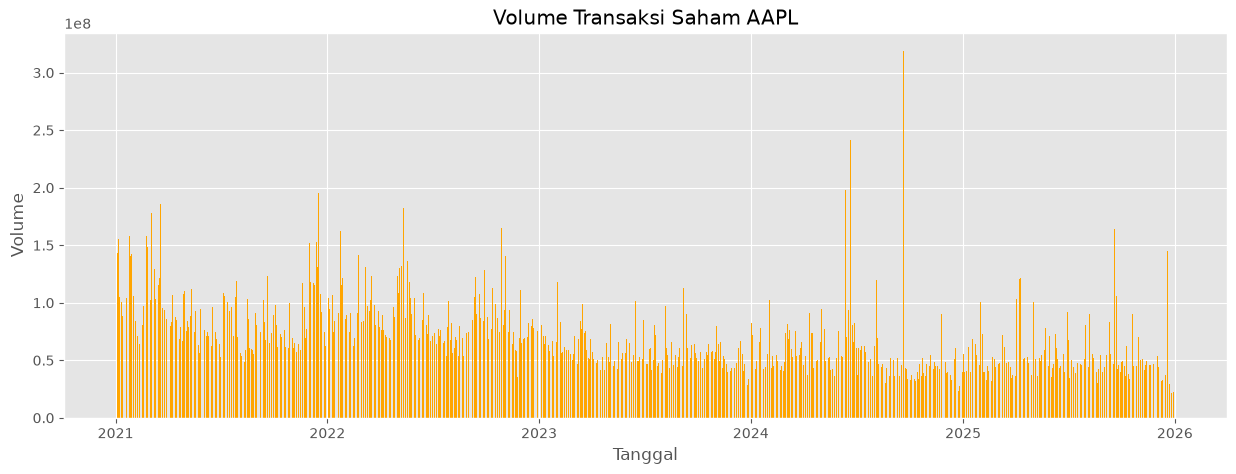

In [25]:
# ==========================================================
# 3.7 VISUALISASI VOLUME
# ==========================================================

plt.figure(figsize=(15,5))

plt.bar(
    df["Date"],
    df["Volume"],
    color="orange"
)

plt.title("Volume Transaksi Saham " + TICKER)

plt.xlabel("Tanggal")

plt.ylabel("Volume")

plt.show()

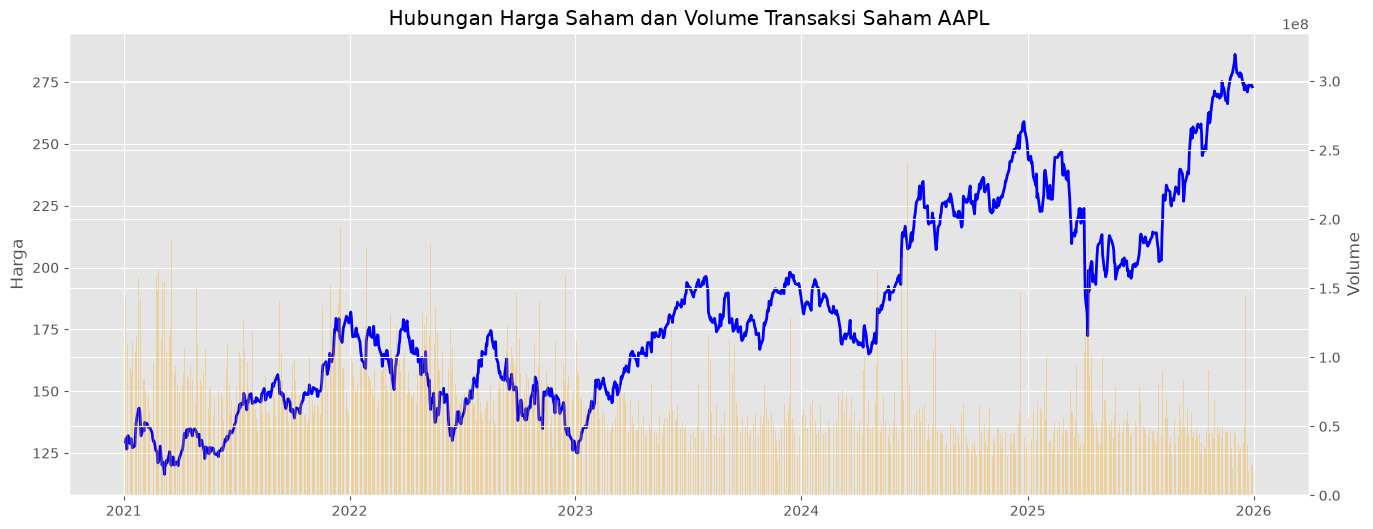

In [26]:
# ==========================================================
# 3.8 HARGA DAN VOLUME
# ==========================================================

fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    df["Date"],
    df["Close"],
    color="blue",
    linewidth=2
)

ax1.set_ylabel("Harga")

ax2 = ax1.twinx()

ax2.bar(
    df["Date"],
    df["Volume"],
    alpha=0.30,
    color="orange"
)

ax2.set_ylabel("Volume")

plt.title("Hubungan Harga Saham dan Volume Transaksi Saham " + TICKER)

plt.show()

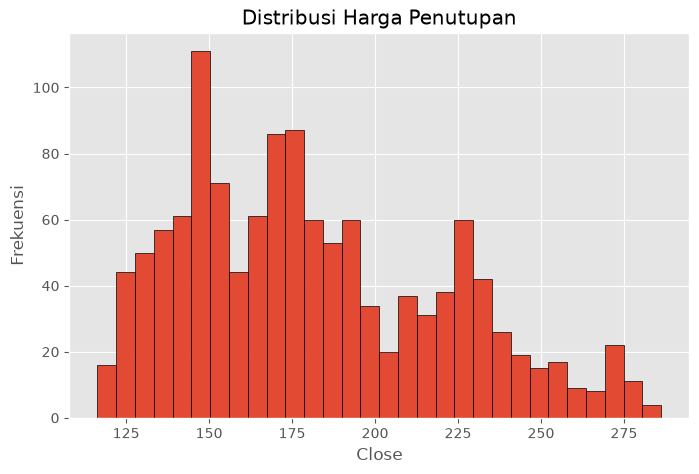

In [27]:
# ==========================================================
# 3.9 DISTRIBUSI HARGA
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    df["Close"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribusi Harga Penutupan")

plt.xlabel("Close")

plt.ylabel("Frekuensi")

plt.show()

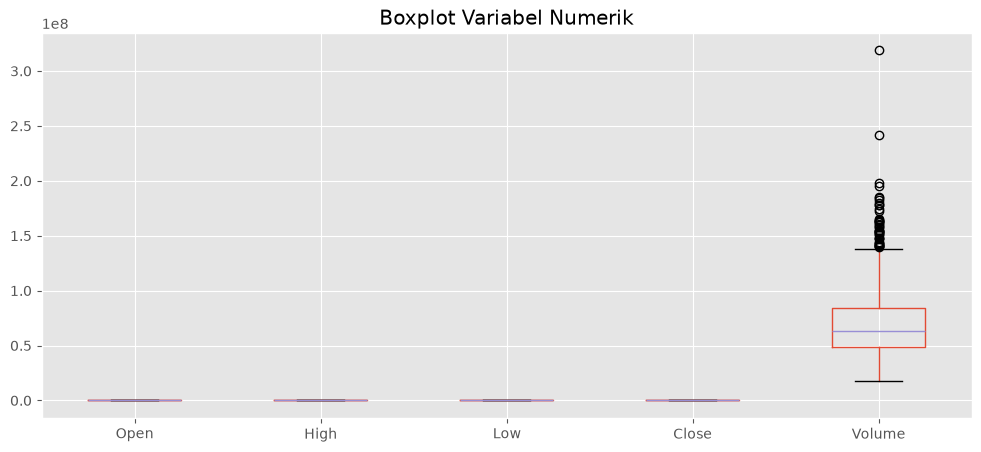

In [28]:
# ==========================================================
# 3.10 BOXPLOT
# ==========================================================

plt.figure(figsize=(12,5))

df[numeric_columns].boxplot()

plt.title("Boxplot Variabel Numerik")

plt.show()

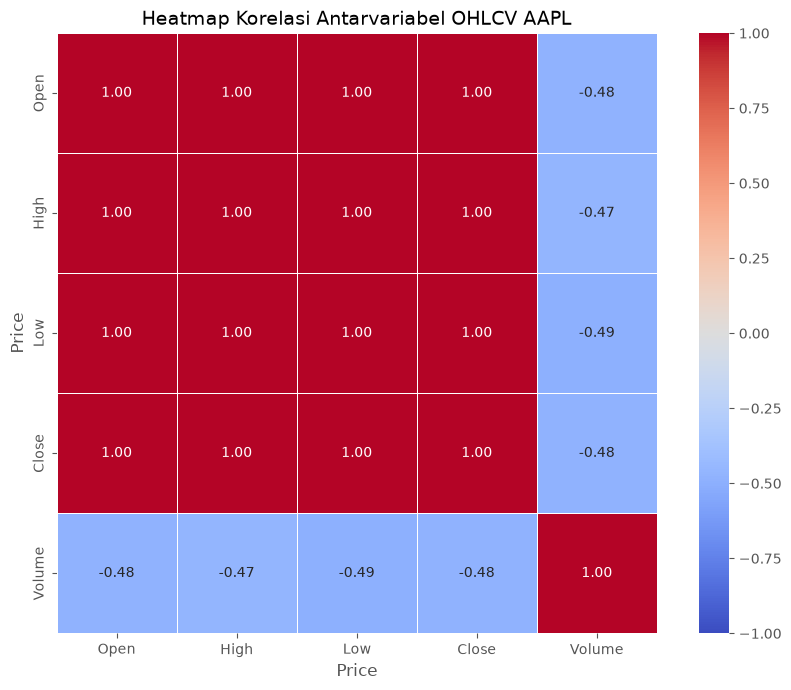

In [29]:
# ==========================================================
# 3.11 HEATMAP KORELASI
# ==========================================================

numeric_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True
)

plt.title(
    "Heatmap Korelasi Antarvariabel OHLCV " + TICKER,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [30]:
# ==========================================================
# 3.12 KESIMPULAN EDA
# ==========================================================

print("="*60)
print("KESIMPULAN EDA")
print("="*60)

print(f"Jumlah Data            : {len(df)}")
print(f"Missing Value          : {df.isnull().sum().sum()}")
print(f"Data Duplikat          : {duplicate}")

print("\nTahap selanjutnya adalah Data Cleaning.")

KESIMPULAN EDA
Jumlah Data            : 1254
Missing Value          : 0
Data Duplikat          : 0

Tahap selanjutnya adalah Data Cleaning.


## 4. Data Cleaning

Tahap Data Cleaning bertujuan untuk memastikan kualitas data sebelum dilakukan proses Feature Engineering. Proses ini meliputi pemeriksaan tipe data, nilai yang hilang (*missing value*), data duplikat, validasi nilai OHLCV, serta pengurutan data berdasarkan tanggal.

Pada penelitian ini, data outlier tidak dihapus karena pada data pasar saham lonjakan harga maupun volume merupakan kondisi yang wajar dan dapat mencerminkan perubahan kondisi pasar akibat berita, aksi korporasi, atau aktivitas perdagangan yang tinggi.

In [31]:
# ==========================================================
# 4.1 MENYALIN DATASET
# ==========================================================

df_clean = df.copy()

print("Jumlah data awal :", len(df_clean))

Jumlah data awal : 1254


In [32]:
# ==========================================================
# 4.2 MEMBERSIHKAN MISSING VALUE
# ==========================================================

print("="*60)
print("PEMERIKSAAN MISSING VALUE")
print("="*60)

print(df_clean.isnull().sum())

print("\nTotal Missing Value :", df_clean.isnull().sum().sum())

# Jika ditemukan Missing Value
df_clean = df_clean.dropna().reset_index(drop=True)

PEMERIKSAAN MISSING VALUE
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Total Missing Value : 0


In [33]:
# ==========================================================
# 4.3 DUPLICATE DATA
# ==========================================================

duplicate = df_clean.duplicated().sum()

print("Jumlah Data Duplikat :", duplicate)

# Jika ditemukan Data Duplikat

if duplicate > 0:

    df_clean = (
        df_clean
        .drop_duplicates()
        .reset_index(drop=True)
    )

Jumlah Data Duplikat : 0


In [34]:
# ==========================================================
# 4.4 VALIDASI NILAI OHLCV
# ==========================================================

print("="*60)
print("VALIDASI NILAI OHLCV")
print("="*60)

print("Open  <= 0 :", (df_clean["Open"] <= 0).sum())
print("High  <= 0 :", (df_clean["High"] <= 0).sum())
print("Low   <= 0 :", (df_clean["Low"] <= 0).sum())
print("Close <= 0 :", (df_clean["Close"] <= 0).sum())
print("Volume<= 0 :", (df_clean["Volume"] <= 0).sum())

# Jika ada nilai 0

df_clean = df_clean[
    (df_clean["Open"] > 0) &
    (df_clean["High"] > 0) &
    (df_clean["Low"] > 0) &
    (df_clean["Close"] > 0) &
    (df_clean["Volume"] > 0)
].reset_index(drop=True)

VALIDASI NILAI OHLCV
Open  <= 0 : 0
High  <= 0 : 0
Low   <= 0 : 0
Close <= 0 : 0
Volume<= 0 : 0


In [35]:
# ==========================================================
# 4.5 VALIDASI STRUKTUR OHLC
# ==========================================================

invalid = df_clean[
    (df_clean["High"] < df_clean["Open"]) |
    (df_clean["High"] < df_clean["Close"]) |
    (df_clean["High"] < df_clean["Low"]) |
    (df_clean["Low"] > df_clean["Open"]) |
    (df_clean["Low"] > df_clean["Close"])
]

print("Jumlah Data Tidak Valid :", len(invalid))

# Jika ada Data tidak valid

display(invalid)

Jumlah Data Tidak Valid : 0


Price,Date,Open,High,Low,Close,Volume


In [36]:
# ==========================================================
# 4.6 SORTING
# ==========================================================

df_clean = (
    df_clean
    .sort_values("Date")
    .reset_index(drop=True)
)

display(df_clean.head())

Price,Date,Open,High,Low,Close,Volume
0,2021-01-04,133.5200,133.6100,126.7600,129.4100,143301900
1,2021-01-05,128.8900,131.7400,128.4300,131.0100,97664900
2,2021-01-06,127.7200,131.0500,126.3800,126.6000,155088000
3,2021-01-07,128.3600,131.6300,127.8600,130.9200,109578200
4,2021-01-08,132.4300,132.6300,130.2300,132.0500,105158200


In [37]:
# ==========================================================
# 4.7 TIPE DATA
# ==========================================================

display(df_clean.dtypes)

Price
Date      datetime64[s]
Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
dtype: object

In [38]:
# ==========================================================
# 4.8 RINGKASAN DATA CLEANING
# ==========================================================

summary = pd.DataFrame({

    "Tahapan":[
        "Dataset Awal",
        "Dataset Setelah Cleaning"
    ],

    "Jumlah Data":[
        len(df),
        len(df_clean)
    ]

})

display(summary)

,Tahapan,Jumlah Data
0,Dataset Awal,1254
1,Dataset Setelah Cleaning,1254


In [39]:
# ==========================================================
# 4.9 DATASET HASIL CLEANING
# ==========================================================

display(df_clean.head(10))

Price,Date,Open,High,Low,Close,Volume
0,2021-01-04,133.5200,133.6100,126.7600,129.4100,143301900
1,2021-01-05,128.8900,131.7400,128.4300,131.0100,97664900
2,2021-01-06,127.7200,131.0500,126.3800,126.6000,155088000
3,2021-01-07,128.3600,131.6300,127.8600,130.9200,109578200
4,2021-01-08,132.4300,132.6300,130.2300,132.0500,105158200
5,2021-01-11,129.1900,130.1700,128.5000,128.9800,100384500
6,2021-01-12,128.5000,129.6900,126.8600,128.8000,91951100
7,2021-01-13,128.7600,131.4500,128.4900,130.8900,88636800
8,2021-01-14,130.8000,131.0000,128.7600,128.9100,90221800
9,2021-01-15,128.7800,130.2200,127.0000,127.1400,111598500


In [40]:
# ==========================================================
# 4.11 KESIMPULAN
# ==========================================================

print("="*60)
print("KESIMPULAN DATA CLEANING")
print("="*60)

print("Jumlah Dataset Awal :", len(df))
print("Jumlah Dataset Bersih :", len(df_clean))

print("\nDataset siap digunakan untuk Feature Engineering.")

KESIMPULAN DATA CLEANING
Jumlah Dataset Awal : 1254
Jumlah Dataset Bersih : 1254

Dataset siap digunakan untuk Feature Engineering.


## 5. Feature Engineering

Feature Engineering merupakan proses membentuk fitur baru dari data OHLCV yang bertujuan untuk merepresentasikan karakteristik pergerakan harga dan volume saham berdasarkan konsep Price–Volume Action.

Pada penelitian ini digunakan lima fitur utama, yaitu:

1. Return
2. Relative Volume (RVOL)
3. Trend
4. Price Position
5. Breakout dan Breakdown

Fitur-fitur tersebut selanjutnya digunakan sebagai dasar pembentukan Rule-Based Labeling dan sebagai variabel masukan pada model Random Forest maupun Support Vector Machine.

In [41]:
# ==========================================================
# 5.1 MENYALIN DATASET
# ==========================================================

df_feature = df_clean.copy()

print("Jumlah Data :", len(df_feature))

Jumlah Data : 1254


In [42]:
# ==========================================================
# 5.2 RETURN
# ==========================================================

df_feature["Return"] = (
    df_feature["Close"]
    .pct_change()
    .fillna(0)
)

display(
    df_feature[
        [
            "Date",
            "Close",
            "Return"
        ]
    ].head()
)

Price,Date,Close,Return
0,2021-01-04,129.4100,0.0000
1,2021-01-05,131.0100,0.0124
2,2021-01-06,126.6000,-0.0337
3,2021-01-07,130.9200,0.0341
4,2021-01-08,132.0500,0.0086


In [43]:
# ==========================================================
# 5.3 RVOL
# ==========================================================

rolling_volume = (
    df_feature["Volume"]
    .rolling(
        window=RVOL_PERIOD,
        min_periods=1
    )
    .mean()
)

df_feature["RVOL"] = (
    df_feature["Volume"] /
    rolling_volume
)

display(
    df_feature[
        [
            "Volume",
            "RVOL"
        ]
    ].head()
)

Price,Volume,RVOL
0,143301900,1.0000
1,97664900,0.8106
2,155088000,1.1747
3,109578200,0.8669
4,105158200,0.8608


In [44]:
# ==========================================================
# 5.4 TREND
# ==========================================================

# ==========================================================
# Moving Average
# ==========================================================

df_feature["MA5"] = (
    df_feature["Close"]
    .rolling(window=MA_SHORT, min_periods=1)
    .mean()
)

df_feature["MA20"] = (
    df_feature["Close"]
    .rolling(window=MA_LONG, min_periods=1)
    .mean()
)

# ==========================================================
# Trend Difference
# ==========================================================

df_feature["TrendDiff"] = (
    (df_feature["MA5"] - df_feature["MA20"])
    / df_feature["MA20"]
)

# ==========================================================
# Menentukan Trend
# ==========================================================

TREND_THRESHOLD = 0.01   # 1%

conditions = [
    df_feature["TrendDiff"] > TREND_THRESHOLD,
    df_feature["TrendDiff"] < -TREND_THRESHOLD
]

choices = [
    "Uptrend",
    "Downtrend"
]

df_feature["Trend"] = np.select(
    conditions,
    choices,
    default="Sideways"
)

In [45]:
# ==========================================================
# 5.5 SUPPORT & RESISTANCE
# ==========================================================

df_feature["Support"] = (

    df_feature["Low"]

    .rolling(

        SR_PERIOD,

        min_periods=1

    )

    .min()

)

df_feature["Resistance"] = (

    df_feature["High"]

    .rolling(

        SR_PERIOD,

        min_periods=1

    )

    .max()

)

In [46]:
# ==========================================================
# 5.6 PRICE POSITION
# ==========================================================

range_price = (

    df_feature["Resistance"]

    -

    df_feature["Support"]

)

range_price = range_price.replace(0, np.nan)

df_feature["PricePosition"] = (

    (

        df_feature["Close"]

        -

        df_feature["Support"]

    )

    /

    range_price

)

df_feature["PricePosition"] = (

    df_feature["PricePosition"]

    .fillna(0.5)

)

In [47]:
# ==========================================================
# 5.7 BREAKOUT
# ==========================================================

df_feature["Breakout"] = np.where(

    df_feature["Close"]

    >

    df_feature["Resistance"].shift(1),

    1,

    0

)

In [48]:
# ==========================================================
# 5.8 BREAKDOWN
# ==========================================================

df_feature["Breakdown"] = np.where(

    df_feature["Close"]

    <

    df_feature["Support"].shift(1),

    1,

    0

)

In [49]:
# ==========================================================
# 5.9 DATASET HASIL FEATURE ENGINEERING
# ==========================================================

display(

    df_feature[

        [

            "Date",

            "Close",

            "Return",

            "RVOL",

            "Trend",

            "PricePosition",

            "Breakout",

            "Breakdown"

        ]

    ].head(10)

)

Price,Date,Close,Return,RVOL,Trend,PricePosition,Breakout,Breakdown
0,2021-01-04,129.4100,0.0000,1.0000,Sideways,0.3869,0,0
1,2021-01-05,131.0100,0.0124,0.8106,Sideways,0.6204,0,0
2,2021-01-06,126.6000,-0.0337,1.1747,Sideways,0.0304,0,1
3,2021-01-07,130.9200,0.0341,0.8669,Sideways,0.6279,0,0
4,2021-01-08,132.0500,0.0086,0.8608,Sideways,0.7842,0,0
5,2021-01-11,128.9800,-0.0232,0.8469,Sideways,0.3596,0,0
6,2021-01-12,128.8000,-0.0014,0.8014,Sideways,0.3347,0,0
7,2021-01-13,130.8900,0.0162,0.7952,Sideways,0.6238,0,0
8,2021-01-14,128.9100,-0.0151,0.8269,Sideways,0.3499,0,0
9,2021-01-15,127.1400,-0.0137,1.0205,Sideways,0.1051,0,0


In [50]:
# ==========================================================
# 5.10 STATISTIK FITUR
# ==========================================================

display(

    df_feature[

        [

            "Return",

            "RVOL",

            "PricePosition"

        ]

    ].describe()

)

Price,Return,RVOL,PricePosition
count,1254.0000,1254.0000,1254.0000
mean,0.0007,0.9982,0.5756
std,0.0175,0.3507,0.3065
min,-0.0925,0.4055,0.0034
25%,-0.0080,0.7970,0.3017
50%,0.0010,0.9169,0.6174
75%,0.0098,1.1162,0.8666
max,0.1533,5.2456,1.0000


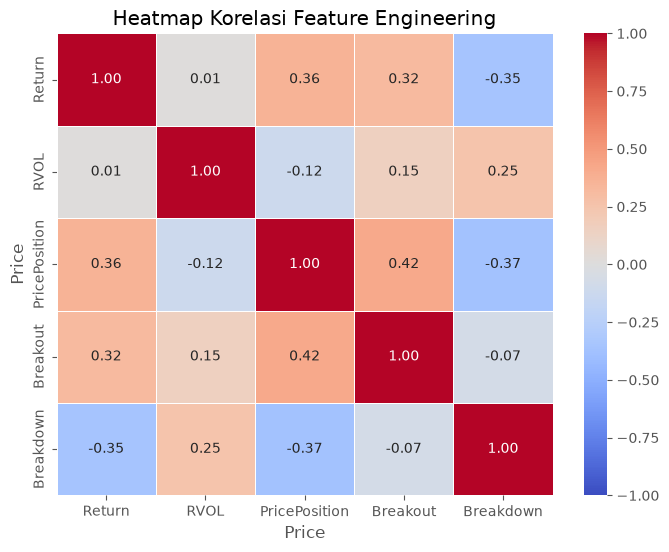

In [51]:
# ==========================================================
# 5.11 HEATMAP FEATURE
# ==========================================================

feature_corr = df_feature[
    [
        "Return",
        "RVOL",
        "PricePosition",
        "Breakout",
        "Breakdown"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    feature_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title("Heatmap Korelasi Feature Engineering")

plt.show()

In [52]:
# ==========================================================
# 5.13 KESIMPULAN
# ==========================================================

print("="*60)
print("KESIMPULAN FEATURE ENGINEERING")
print("="*60)

print("Jumlah Dataset :", len(df_feature))

print("Jumlah Feature Baru :", 8)

print("\nDataset siap digunakan pada Rule-Based Labeling.")

KESIMPULAN FEATURE ENGINEERING
Jumlah Dataset : 1254
Jumlah Feature Baru : 8

Dataset siap digunakan pada Rule-Based Labeling.


## 6. Rule-Based Labeling

Rule-Based Labeling merupakan proses pemberian label secara otomatis terhadap setiap data berdasarkan seperangkat aturan yang disusun dari teori Wyckoff dan konsep Price–Volume Action.

Pada penelitian ini digunakan empat label utama, yaitu:

- Akumulasi
- Markup
- Distribusi
- Markdown

Penentuan label dilakukan menggunakan kombinasi lima fitur hasil Feature Engineering, yaitu Return, Relative Volume (RVOL), Trend, Price Position, Breakout, dan Breakdown.

Pendekatan ini dipilih untuk mengurangi subjektivitas pelabelan manual sekaligus menghasilkan dataset target yang dapat digunakan pada proses klasifikasi menggunakan algoritma Random Forest dan Support Vector Machine.

In [53]:
# ==========================================================
# 6.1 COPY DATASET
# ==========================================================

df_label = df_feature.copy()

print("Jumlah Dataset :", len(df_label))

Jumlah Dataset : 1254


In [54]:
# ==========================================================
# 6.2 THRESHOLD
# ==========================================================

RVOL_HIGH = 1.20

RETURN_POSITIVE = 0.01

RETURN_NEGATIVE = -0.01

LOW_POSITION = 0.35

HIGH_POSITION = 0.65

In [55]:
# ==========================================================
# RULE-BASED LABELING BERDASARKAN TEORI WYCKOFF
# ==========================================================

def wyckoff_label(row):

    # -------------------------
    # AKUMULASI
    # -------------------------
    if (
        row["Trend"] == "Sideways"
        and row["PricePosition"] <= LOW_POSITION
        and row["RVOL"] >= RVOL_HIGH
    ):
        return "Akumulasi"

    # -------------------------
    # MARKUP
    # -------------------------
    elif (
        row["Trend"] == "Uptrend"
        and row["Breakout"] == 1
        and row["Return"] >= RETURN_POSITIVE
        and row["RVOL"] >= RVOL_HIGH
    ):
        return "Markup"

    # -------------------------
    # DISTRIBUSI
    # -------------------------
    elif (
        row["Trend"] == "Sideways"
        and row["PricePosition"] >= HIGH_POSITION
        and row["RVOL"] >= RVOL_HIGH
    ):
        return "Distribusi"

    # -------------------------
    # MARKDOWN
    # -------------------------
    elif (
        row["Trend"] == "Downtrend"
        and row["Breakdown"] == 1
        and row["Return"] <= RETURN_NEGATIVE
        and row["RVOL"] >= RVOL_HIGH
    ):
        return "Markdown"

    return np.nan

df_label["Confidence"] = np.where(
    df_label["RVOL"] >= 1.5,
    "High",
    np.where(
        df_label["RVOL"] >= 1.2,
        "Medium",
        "Low"
    )
)

In [56]:
# ==========================================================
# 6.5 LABELING
# ==========================================================

df_label["Label"] = df_label.apply(

    wyckoff_label,

    axis=1

)

In [57]:
# ==========================================================
# 6.6 STATE PERSISTENCE
# ==========================================================

df_label["Label"] = (

    df_label["Label"]

    .ffill()

)

df_label["Label"] = (

    df_label["Label"]

    .fillna("Akumulasi")

)

In [58]:
# ==========================================================
# 6.7 DISTRIBUSI LABEL
# ==========================================================

label_summary = (

    df_label["Label"]

    .value_counts()

    .reset_index()

)

label_summary.columns = [

    "Label",

    "Jumlah"

]

display(label_summary)

,Label,Jumlah
0,Markdown,420
1,Markup,409
2,Distribusi,219
3,Akumulasi,206


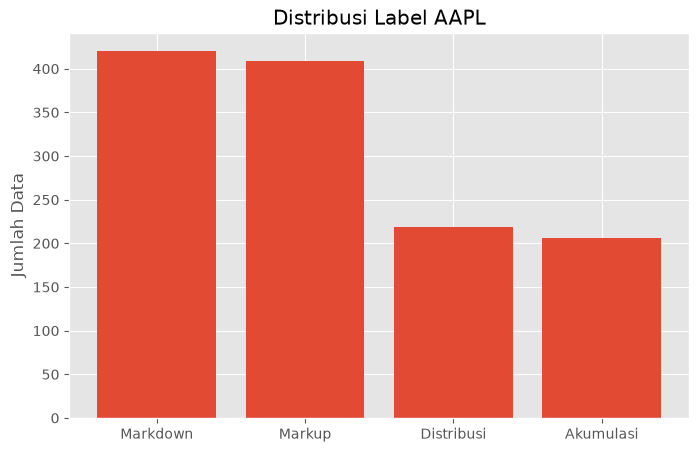

In [59]:
# ==========================================================
# 6.8 BAR CHART
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(

    label_summary["Label"],

    label_summary["Jumlah"]

)

plt.title(

    "Distribusi Label "+ TICKER

)

plt.ylabel("Jumlah Data")

plt.show()

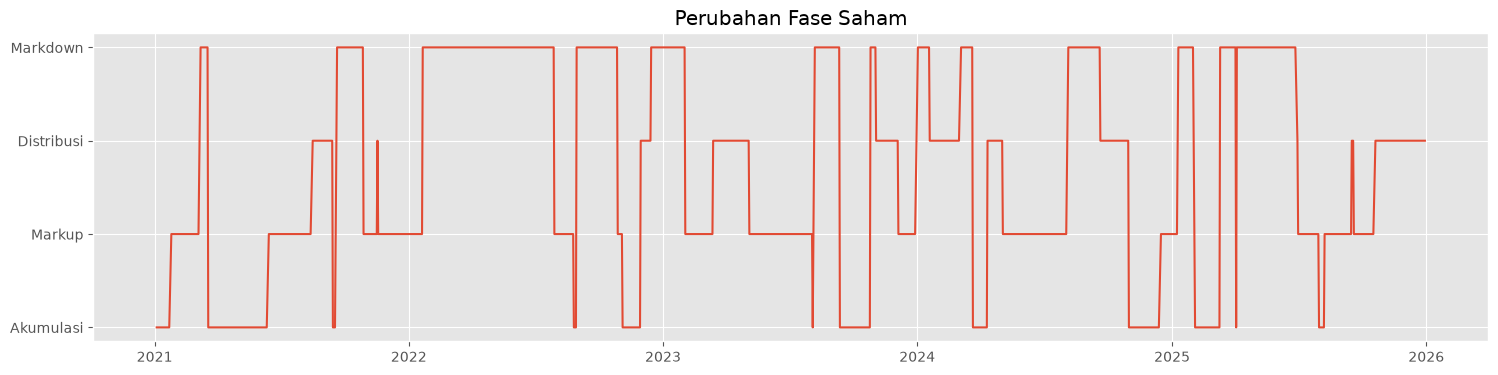

In [60]:
# ==========================================================
# 6.9 TIMELINE LABEL
# ==========================================================

label_map = {

    "Akumulasi":0,

    "Markup":1,

    "Distribusi":2,

    "Markdown":3

}

timeline = (

    df_label["Label"]

    .map(label_map)

)

plt.figure(figsize=(18,4))

plt.plot(

    df_label["Date"],

    timeline

)

plt.yticks(

    [0,1,2,3],

    [

        "Akumulasi",

        "Markup",

        "Distribusi",

        "Markdown"

    ]

)

plt.title(

    "Perubahan Fase Saham"

)

plt.show()

In [61]:
display(

    df_label[

        [

            "Date",

            "Return",

            "RVOL",

            "Trend",

            "PricePosition",

            "Breakout",

            "Breakdown",

            "Label"

        ]

    ].head(15)

)

Price,Date,Return,RVOL,Trend,PricePosition,Breakout,Breakdown,Label
0,2021-01-04,0.0000,1.0000,Sideways,0.3869,0,0,Akumulasi
1,2021-01-05,0.0124,0.8106,Sideways,0.6204,0,0,Akumulasi
2,2021-01-06,-0.0337,1.1747,Sideways,0.0304,0,1,Akumulasi
3,2021-01-07,0.0341,0.8669,Sideways,0.6279,0,0,Akumulasi
4,2021-01-08,0.0086,0.8608,Sideways,0.7842,0,0,Akumulasi
5,2021-01-11,-0.0232,0.8469,Sideways,0.3596,0,0,Akumulasi
6,2021-01-12,-0.0014,0.8014,Sideways,0.3347,0,0,Akumulasi
7,2021-01-13,0.0162,0.7952,Sideways,0.6238,0,0,Akumulasi
8,2021-01-14,-0.0151,0.8269,Sideways,0.3499,0,0,Akumulasi
9,2021-01-15,-0.0137,1.0205,Sideways,0.1051,0,0,Akumulasi


In [62]:
print("="*60)

print("KESIMPULAN RULE-BASED LABELING")

print("="*60)

print("Jumlah Dataset :",len(df_label))

print()

print(label_summary)

KESIMPULAN RULE-BASED LABELING
Jumlah Dataset : 1254

        Label  Jumlah
0    Markdown     420
1      Markup     409
2  Distribusi     219
3   Akumulasi     206


## 7. Pembagian Data Training dan Testing

Dataset dibagi menjadi 80% data training dan 20% data testing berdasarkan urutan waktu. Data pada periode awal digunakan sebagai data training, sedangkan data pada periode terbaru digunakan sebagai data testing.

Pembagian secara kronologis dilakukan untuk menjaga karakteristik deret waktu dan mencegah terjadinya data leakage akibat tercampurnya informasi masa depan ke dalam data training.

In [63]:
# ==========================================================
# 7.1 MENENTUKAN FEATURE DAN TARGET
# ==========================================================

feature_columns = [
    "Return",
    "RVOL",
    "TrendDiff",
    "PricePosition",
    "Breakout",
    "Breakdown"
]

target_column = "Label"

# Validasi kolom
required_model_columns = feature_columns + [target_column, "Date"]

missing_columns = [
    col for col in required_model_columns
    if col not in df_label.columns
]

if missing_columns:
    raise ValueError(
        f"Kolom untuk pemodelan belum lengkap: {missing_columns}"
    )

X = df_label[feature_columns].copy()
y = df_label[target_column].copy()

print("Feature yang digunakan:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Feature yang digunakan:
['Return', 'RVOL', 'TrendDiff', 'PricePosition', 'Breakout', 'Breakdown']

Target:
Label


In [64]:
# ==========================================================
# 7.2 PEMERIKSAAN NILAI KOSONG
# ==========================================================

print("Missing value pada feature:")
display(X.isnull().sum())

print("Missing value pada target:")
print(y.isnull().sum())

# ==========================================================
# MENGHAPUS NILAI KOSONG SECARA SINKRON
# ==========================================================

model_data = df_label[
    ["Date", "Close"] + feature_columns + [target_column]
].copy()

before_drop = len(model_data)

model_data = (
    model_data
    .dropna(subset=feature_columns + [target_column])
    .sort_values("Date")
    .reset_index(drop=True)
)

after_drop = len(model_data)

print("Data sebelum validasi :", before_drop)
print("Data setelah validasi :", after_drop)
print("Data dihapus          :", before_drop - after_drop)

Missing value pada feature:


Price
Return           0
RVOL             0
TrendDiff        0
PricePosition    0
Breakout         0
Breakdown        0
dtype: int64

Missing value pada target:
0
Data sebelum validasi : 1254
Data setelah validasi : 1254
Data dihapus          : 0


In [65]:
# ==========================================================
# 7.3 MENENTUKAN SPLIT INDEX
# ==========================================================

split_index = int(
    len(model_data) * (1 - TEST_SIZE)
)

print("Total data  :", len(model_data))
print("Split index :", split_index)

Total data  : 1254
Split index : 1003


In [66]:
# ==========================================================
# 7.4 CHRONOLOGICAL TRAIN/TEST SPLIT
# ==========================================================

train_data = (
    model_data
    .iloc[:split_index]
    .copy()
    .reset_index(drop=True)
)

test_data = (
    model_data
    .iloc[split_index:]
    .copy()
    .reset_index(drop=True)
)

X_train = train_data[feature_columns].copy()
y_train = train_data[target_column].copy()

X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].copy()

In [67]:
# ==========================================================
# 7.5 VALIDASI TRAIN/TEST SPLIT
# ==========================================================

print("=" * 60)
print("HASIL PEMBAGIAN DATA")
print("=" * 60)

print(f"Total dataset   : {len(model_data)}")
print(f"Data training   : {len(train_data)}")
print(f"Data testing    : {len(test_data)}")

print(
    f"Persentase train: "
    f"{len(train_data) / len(model_data) * 100:.2f}%"
)

print(
    f"Persentase test : "
    f"{len(test_data) / len(model_data) * 100:.2f}%"
)

print("\nPeriode training:")
print(
    train_data["Date"].min().date(),
    "s.d.",
    train_data["Date"].max().date()
)

print("\nPeriode testing:")
print(
    test_data["Date"].min().date(),
    "s.d.",
    test_data["Date"].max().date()
)

assert (
    train_data["Date"].max()
    < test_data["Date"].min()
), "Periode training dan testing tidak kronologis."

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

print("\nValidasi pembagian data berhasil.")

HASIL PEMBAGIAN DATA
Total dataset   : 1254
Data training   : 1003
Data testing    : 251
Persentase train: 79.98%
Persentase test : 20.02%

Periode training:
2021-01-04 s.d. 2024-12-27

Periode testing:
2024-12-30 s.d. 2025-12-30

Validasi pembagian data berhasil.


In [68]:
# ==========================================================
# 7.6 DATASET TRAINING
# ==========================================================

print("Dataset Training")
display(train_data.head(10))

# ==========================================================
# DATASET TESTING
# ==========================================================

print("Dataset Testing")
display(test_data.head(10))

Dataset Training


Price,Date,Close,Return,RVOL,TrendDiff,PricePosition,Breakout,Breakdown,Label
0,2021-01-04,129.4100,0.0000,1.0000,0.0000,0.3869,0,0,Akumulasi
1,2021-01-05,131.0100,0.0124,0.8106,0.0000,0.6204,0,0,Akumulasi
2,2021-01-06,126.6000,-0.0337,1.1747,0.0000,0.0304,0,1,Akumulasi
3,2021-01-07,130.9200,0.0341,0.8669,0.0000,0.6279,0,0,Akumulasi
4,2021-01-08,132.0500,0.0086,0.8608,0.0000,0.7842,0,0,Akumulasi
5,2021-01-11,128.9800,-0.0232,0.8469,0.0006,0.3596,0,0,Akumulasi
6,2021-01-12,128.8000,-0.0014,0.8014,-0.0016,0.3347,0,0,Akumulasi
7,2021-01-13,130.8900,0.0162,0.7952,0.0038,0.6238,0,0,Akumulasi
8,2021-01-14,128.9100,-0.0151,0.8269,0.0015,0.3499,0,0,Akumulasi
9,2021-01-15,127.1400,-0.0137,1.0205,-0.0041,0.1051,0,0,Akumulasi


Dataset Testing


Price,Date,Close,Return,RVOL,TrendDiff,PricePosition,Breakout,Breakdown,Label
0,2024-12-30,252.2000,-0.0133,0.7578,0.0272,0.6556,0,0,Markup
1,2024-12-31,250.4200,-0.0071,0.8492,0.0211,0.5434,0,0,Markup
2,2025-01-02,243.8500,-0.0262,1.1776,0.0094,0.1379,0,0,Markup
3,2025-01-03,243.3600,-0.0020,0.8540,-0.0032,0.0877,0,0,Markup
4,2025-01-06,245.0000,0.0067,0.9508,-0.0121,0.1771,0,0,Markup
5,2025-01-07,242.2100,-0.0114,0.8588,-0.0199,0.0459,0,0,Markup
6,2025-01-08,242.7000,0.0020,0.7968,-0.0253,0.1322,0,0,Markup
7,2025-01-10,236.8500,-0.0241,1.2733,-0.0288,0.1421,0,1,Markdown
8,2025-01-13,234.4000,-0.0103,1.0194,-0.0337,0.1540,0,0,Markdown
9,2025-01-14,233.2800,-0.0048,0.8045,-0.0403,0.1172,0,0,Markdown


,Training,Testing
Label,,
Markup,334,75
Markdown,330,90
Akumulasi,174,32
Distribusi,165,54


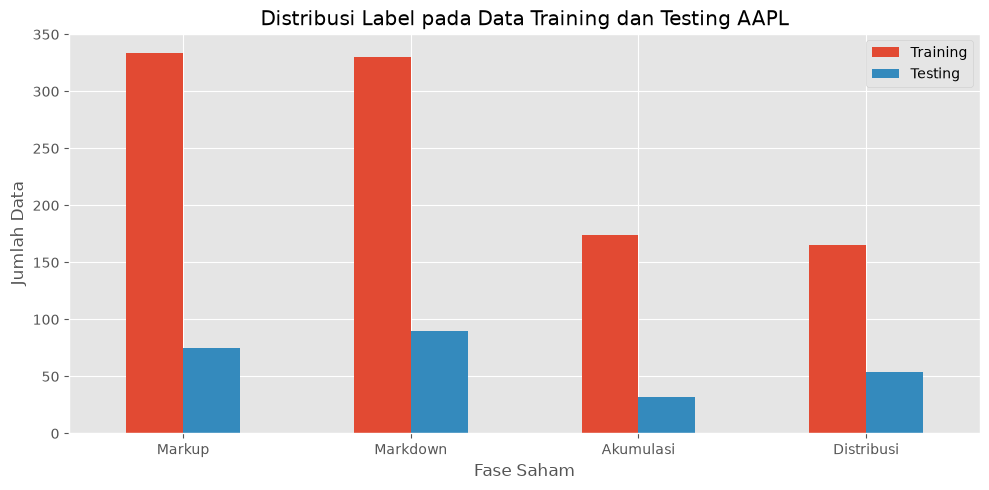

In [69]:
# ==========================================================
# 7.7 DISTRIBUSI LABEL
# ==========================================================

train_distribution = (
    y_train
    .value_counts()
    .rename("Training")
)

test_distribution = (
    y_test
    .value_counts()
    .rename("Testing")
)

split_distribution = pd.concat(
    [
        train_distribution,
        test_distribution
    ],
    axis=1
).fillna(0).astype(int)

display(split_distribution)

split_distribution.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Distribusi Label pada Data Training dan Testing "+ TICKER
)

plt.xlabel("Fase Saham")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

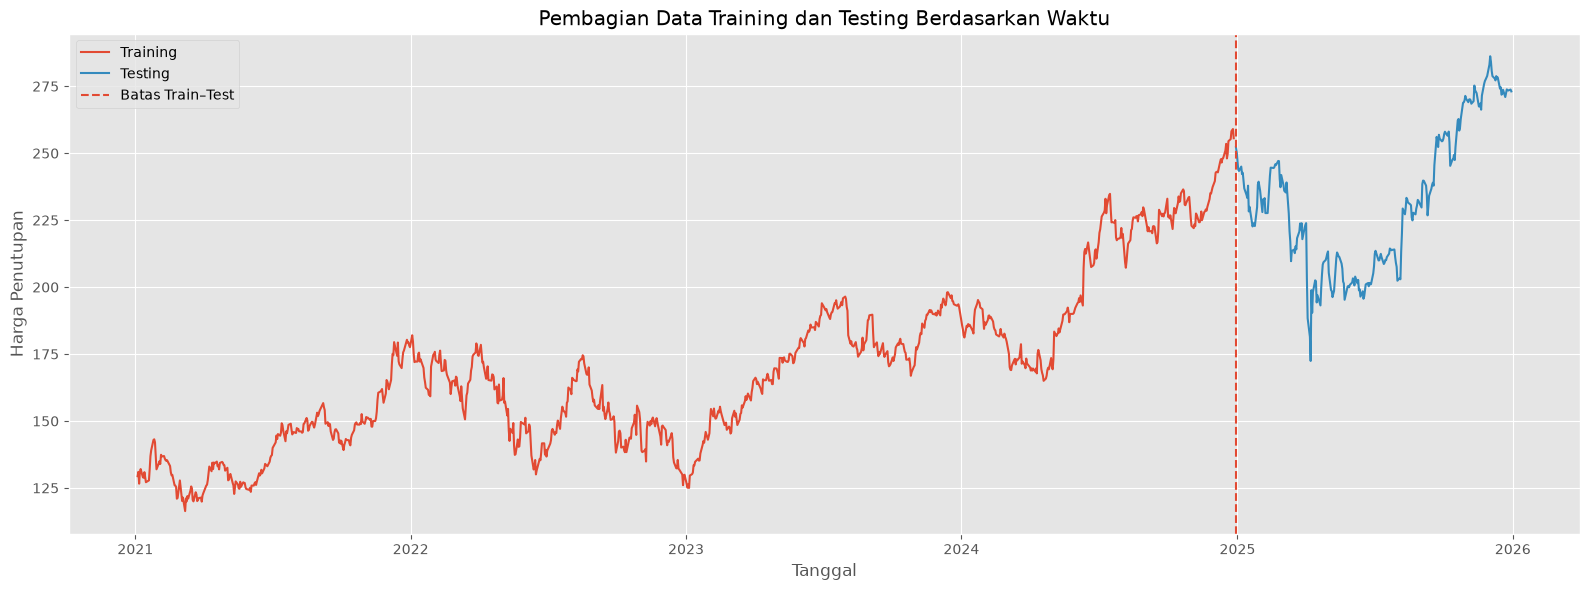

In [70]:
# ==========================================================
# 7.8 VISUALISASI TRAIN/TEST BERDASARKAN WAKTU
# ==========================================================

plt.figure(figsize=(16, 6))

plt.plot(
    train_data["Date"],
    train_data["Close"],
    label="Training"
)

plt.plot(
    test_data["Date"],
    test_data["Close"],
    label="Testing"
)

plt.axvline(
    test_data["Date"].min(),
    linestyle="--",
    label="Batas Train–Test"
)

plt.title(
    "Pembagian Data Training dan Testing Berdasarkan Waktu"
)

plt.xlabel("Tanggal")
plt.ylabel("Harga Penutupan")
plt.legend()
plt.tight_layout()
plt.show()

In [71]:
# ==========================================================
# 7.9 RINGKASAN TRAIN/TEST SPLIT
# ==========================================================

split_summary = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Jumlah Data": [
        len(train_data),
        len(test_data)
    ],
    "Persentase (%)": [
        len(train_data) / len(model_data) * 100,
        len(test_data) / len(model_data) * 100
    ],
    "Tanggal Awal": [
        train_data["Date"].min().date(),
        test_data["Date"].min().date()
    ],
    "Tanggal Akhir": [
        train_data["Date"].max().date(),
        test_data["Date"].max().date()
    ]
})

display(split_summary)

,Dataset,Jumlah Data,Persentase (%),Tanggal Awal,Tanggal Akhir
0,Training,1003,79.9841,2021-01-04,2024-12-27
1,Testing,251,20.0159,2024-12-30,2025-12-30


## 8. Random Forest

Pada tahap ini dilakukan pelatihan model Random Forest untuk mengklasifikasikan empat fase utama saham berdasarkan fitur Price–Volume Action.

Parameter model dioptimasi menggunakan GridSearchCV dengan cross-validation sebanyak 5 fold. Model terbaik dipilih berdasarkan nilai Macro F1-Score karena penelitian ini menggunakan klasifikasi multikelas.

In [72]:
# ==========================================================
# RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [73]:
# ==========================================================
# PARAMETER GRID
# ==========================================================

rf_param_grid = {

    "n_estimators":[
        100,
        200
    ],

    "max_depth":[
        5,
        8,
        None
    ],

    "min_samples_leaf":[
        1,
        5
    ],

    "max_features":[
        "sqrt"
    ]

}

In [74]:
# ==========================================================
# GRID SEARCH
# ==========================================================

rf_grid = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
    ),

    param_grid=rf_param_grid,

    cv=5,

    scoring="f1_macro",

    n_jobs=-1

)

rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 8, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose

In [75]:
# ==========================================================
# BEST PARAMETER
# ==========================================================

print("="*60)

print("BEST PARAMETER RANDOM FOREST")

print("="*60)

print(rf_grid.best_params_)

print()

print("Best Score :",rf_grid.best_score_)

BEST PARAMETER RANDOM FOREST
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}

Best Score : 0.44135995819358487


In [76]:
# ==========================================================
# BEST MODEL
# ==========================================================

rf_model = rf_grid.best_estimator_

In [77]:
# ==========================================================
# PREDIKSI
# ==========================================================

rf_prediction = rf_model.predict(
    X_test
)

In [78]:
# ==========================================================
# METRIK EVALUASI
# ==========================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_prediction
)

rf_precision = precision_score(
    y_test,
    rf_prediction,
    average="macro"
)

rf_recall = recall_score(
    y_test,
    rf_prediction,
    average="macro"
)

rf_f1 = f1_score(
    y_test,
    rf_prediction,
    average="macro"
)

In [79]:
# ==========================================================
# HASIL EVALUASI
# ==========================================================

rf_result = pd.DataFrame({

    "Metrik":[
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1"
    ],

    "Nilai":[

        rf_accuracy,

        rf_precision,

        rf_recall,

        rf_f1

    ]

})

display(
    rf_result
)

,Metrik,Nilai
0,Accuracy,0.5060
1,Precision,0.4761
2,Recall,0.4336
3,Macro F1,0.4100


In [80]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

report = classification_report(

    y_test,

    rf_prediction,

    output_dict=True

)

rf_report = pd.DataFrame(
    report
).transpose()

display(
    rf_report
)

,precision,recall,f1-score,support
Akumulasi,0.2059,0.2188,0.2121,32.0000
Distribusi,0.4615,0.1111,0.1791,54.0000
Markdown,0.7879,0.5778,0.6667,90.0000
Markup,0.4493,0.8267,0.5822,75.0000
accuracy,0.5060,0.5060,0.5060,0.5060
macro avg,0.4761,0.4336,0.4100,251.0000
weighted avg,0.5423,0.5060,0.4786,251.0000


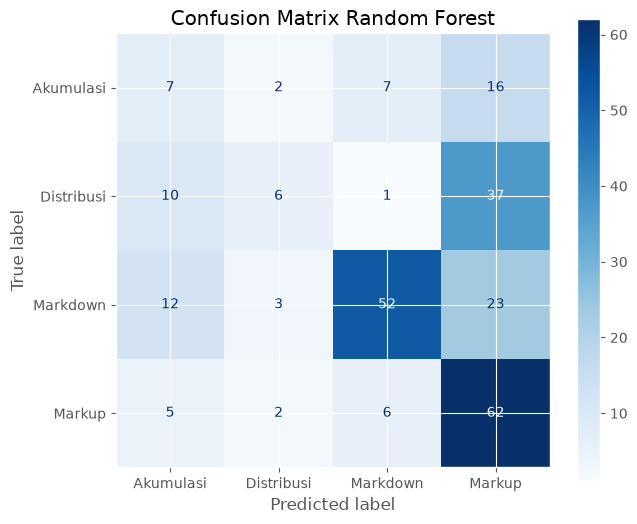

In [81]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    rf_prediction,

    labels=rf_model.classes_

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=rf_model.classes_

)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    ax=ax
)

plt.title(
    "Confusion Matrix Random Forest"
)

plt.show()

In [82]:
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature":feature_columns,

    "Importance":rf_model.feature_importances_

})

importance = (

    importance

    .sort_values(

        "Importance",

        ascending=False

    )

)

display(
    importance
)

,Feature,Importance
2,TrendDiff,0.4647
3,PricePosition,0.2526
1,RVOL,0.1357
0,Return,0.1065
5,Breakdown,0.0236
4,Breakout,0.0169


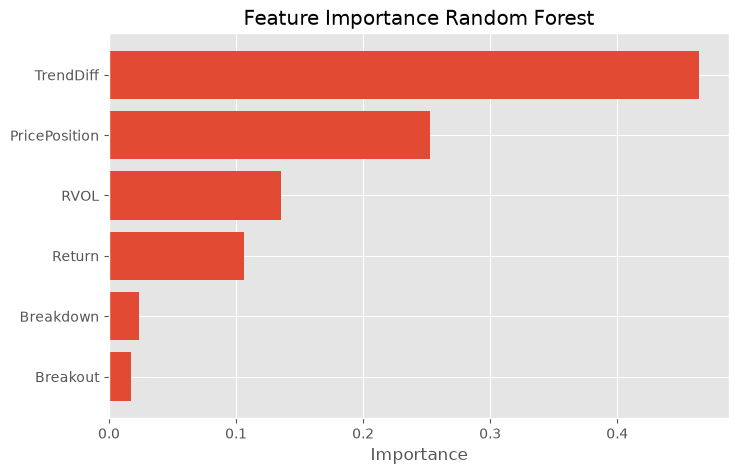

In [ ]:
# ==========================================================
# FEATURE IMPORTANCE CHART
# ==========================================================

plt.figure(figsize=(8,5))

plt.barh(

    importance["Feature"],

    importance["Importance"]

)

plt.title(
    "Feature Importance Random Forest pada dataset "+ TICKER
)

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [84]:
# ==========================================================
# DATASET HASIL PREDIKSI
# ==========================================================

rf_prediction_df = test_data.copy()

rf_prediction_df["Actual"] = y_test.values

rf_prediction_df["Prediction"] = rf_prediction

In [85]:
# ==========================================================
# STATUS PREDIKSI
# ==========================================================

rf_prediction_df["PredictionStatus"] = np.where(

    rf_prediction_df["Actual"]

    ==

    rf_prediction_df["Prediction"],

    "Benar",

    "Salah"

)

display(

    rf_prediction_df.head(20)

)

Price,Date,Close,Return,RVOL,TrendDiff,PricePosition,Breakout,Breakdown,Label,Actual,Prediction,PredictionStatus
0,2024-12-30,252.2000,-0.0133,0.7578,0.0272,0.6556,0,0,Markup,Markup,Markup,Benar
1,2024-12-31,250.4200,-0.0071,0.8492,0.0211,0.5434,0,0,Markup,Markup,Markup,Benar
2,2025-01-02,243.8500,-0.0262,1.1776,0.0094,0.1379,0,0,Markup,Markup,Akumulasi,Salah
3,2025-01-03,243.3600,-0.0020,0.8540,-0.0032,0.0877,0,0,Markup,Markup,Akumulasi,Salah
4,2025-01-06,245.0000,0.0067,0.9508,-0.0121,0.1771,0,0,Markup,Markup,Akumulasi,Salah
5,2025-01-07,242.2100,-0.0114,0.8588,-0.0199,0.0459,0,0,Markup,Markup,Markdown,Salah
6,2025-01-08,242.7000,0.0020,0.7968,-0.0253,0.1322,0,0,Markup,Markup,Markdown,Salah
7,2025-01-10,236.8500,-0.0241,1.2733,-0.0288,0.1421,0,1,Markdown,Markdown,Markdown,Benar
8,2025-01-13,234.4000,-0.0103,1.0194,-0.0337,0.1540,0,0,Markdown,Markdown,Markdown,Benar
9,2025-01-14,233.2800,-0.0048,0.8045,-0.0403,0.1172,0,0,Markdown,Markdown,Markdown,Benar


In [86]:
print("="*60)

print("KESIMPULAN RANDOM FOREST")

print("="*60)

print("Accuracy :",round(rf_accuracy,4))

print("Precision :",round(rf_precision,4))

print("Recall :",round(rf_recall,4))

print("Macro F1 :",round(rf_f1,4))

KESIMPULAN RANDOM FOREST
Accuracy : 0.506
Precision : 0.4761
Recall : 0.4336
Macro F1 : 0.41


,Actual,Prediction
Akumulasi,32,34
Distribusi,54,13
Markdown,90,66
Markup,75,138


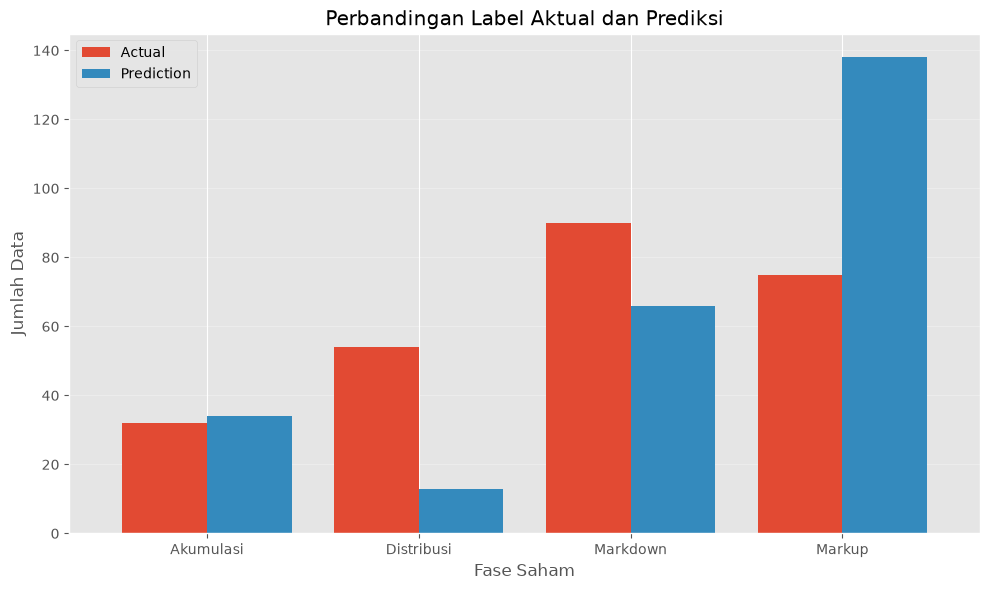

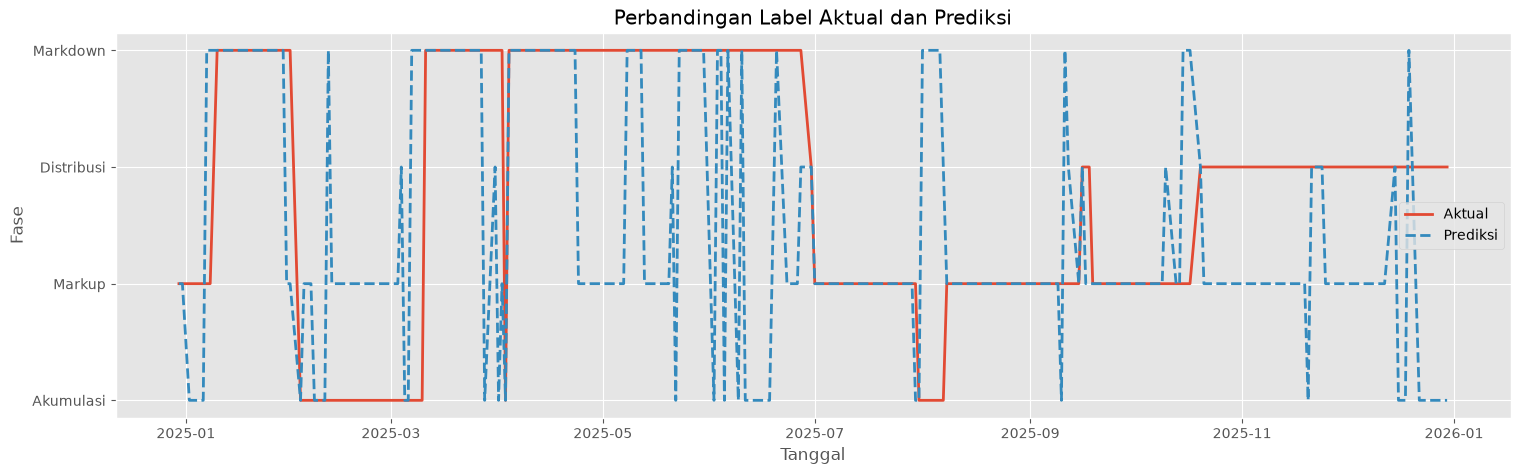

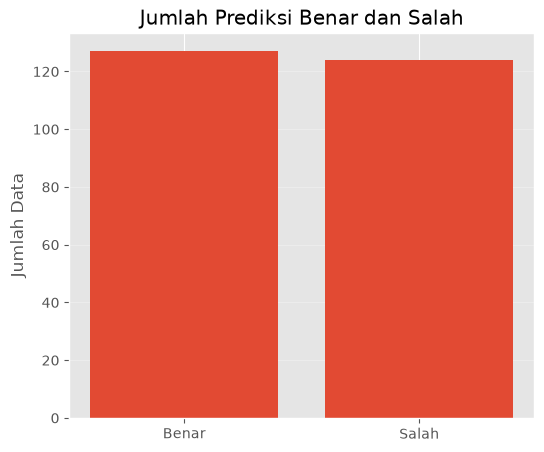

In [87]:
# ==========================================================
# PERBANDINGAN LABEL AKTUAL VS PREDIKSI
# ==========================================================

actual_count = (
    pd.Series(y_test)
    .value_counts()
    .sort_index()
)

prediction_count = (
    pd.Series(rf_prediction)
    .value_counts()
    .sort_index()
)

comparison = pd.DataFrame({
    "Actual": actual_count,
    "Prediction": prediction_count
}).fillna(0)

display(comparison)

# ==========================================================
# BAR CHART
# ==========================================================

comparison.plot(
    kind="bar",
    figsize=(10,6),
    width=0.8
)

plt.title("Perbandingan Label Aktual dan Prediksi")

plt.xlabel("Fase Saham")

plt.ylabel("Jumlah Data")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

# ==========================================================
# TIMELINE LABEL
# ==========================================================

label_map = {
    "Akumulasi":0,
    "Markup":1,
    "Distribusi":2,
    "Markdown":3
}

actual_numeric = (
    rf_prediction_df["Actual"]
    .map(label_map)
)

prediction_numeric = (
    rf_prediction_df["Prediction"]
    .map(label_map)
)

plt.figure(figsize=(18,5))

plt.plot(
    rf_prediction_df["Date"],
    actual_numeric,
    linewidth=2,
    label="Aktual"
)

plt.plot(
    rf_prediction_df["Date"],
    prediction_numeric,
    linestyle="--",
    linewidth=2,
    label="Prediksi"
)

plt.yticks(
    [0,1,2,3],
    [
        "Akumulasi",
        "Markup",
        "Distribusi",
        "Markdown"
    ]
)

plt.title("Perbandingan Label Aktual dan Prediksi")

plt.xlabel("Tanggal")

plt.ylabel("Fase")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# VISUALISASI HASIL PREDIKSI
# ==========================================================

status = (
    rf_prediction_df["PredictionStatus"]
    .value_counts()
)

plt.figure(figsize=(6,5))

plt.bar(
    status.index,
    status.values
)

plt.title("Jumlah Prediksi Benar dan Salah")

plt.ylabel("Jumlah Data")

plt.grid(axis="y", alpha=0.3)

plt.show()

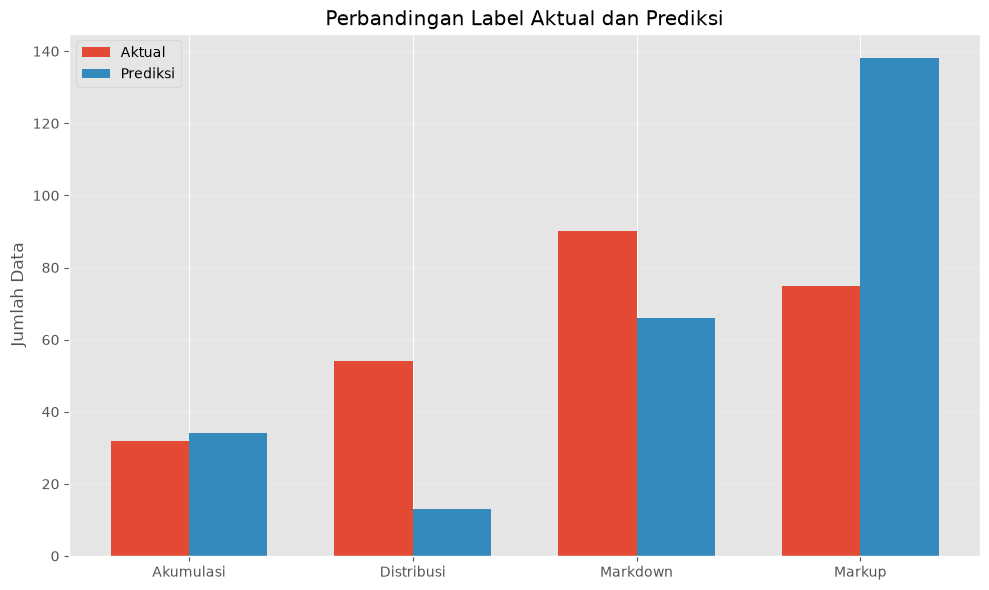

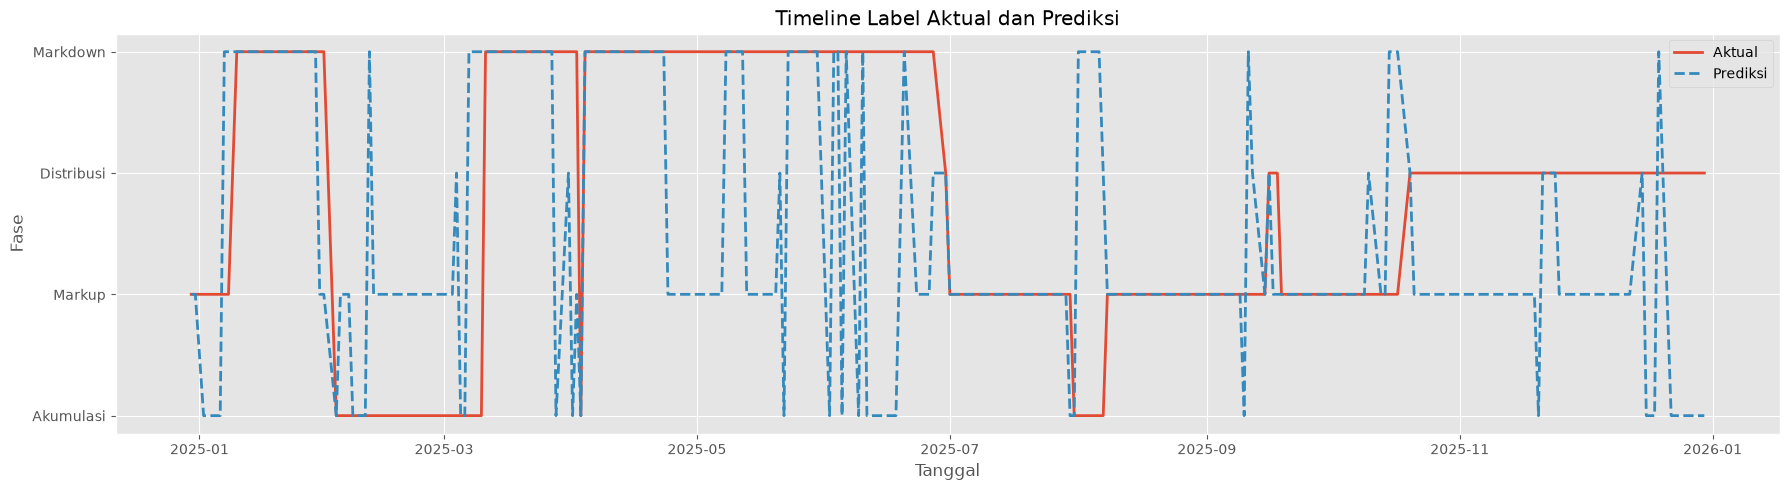

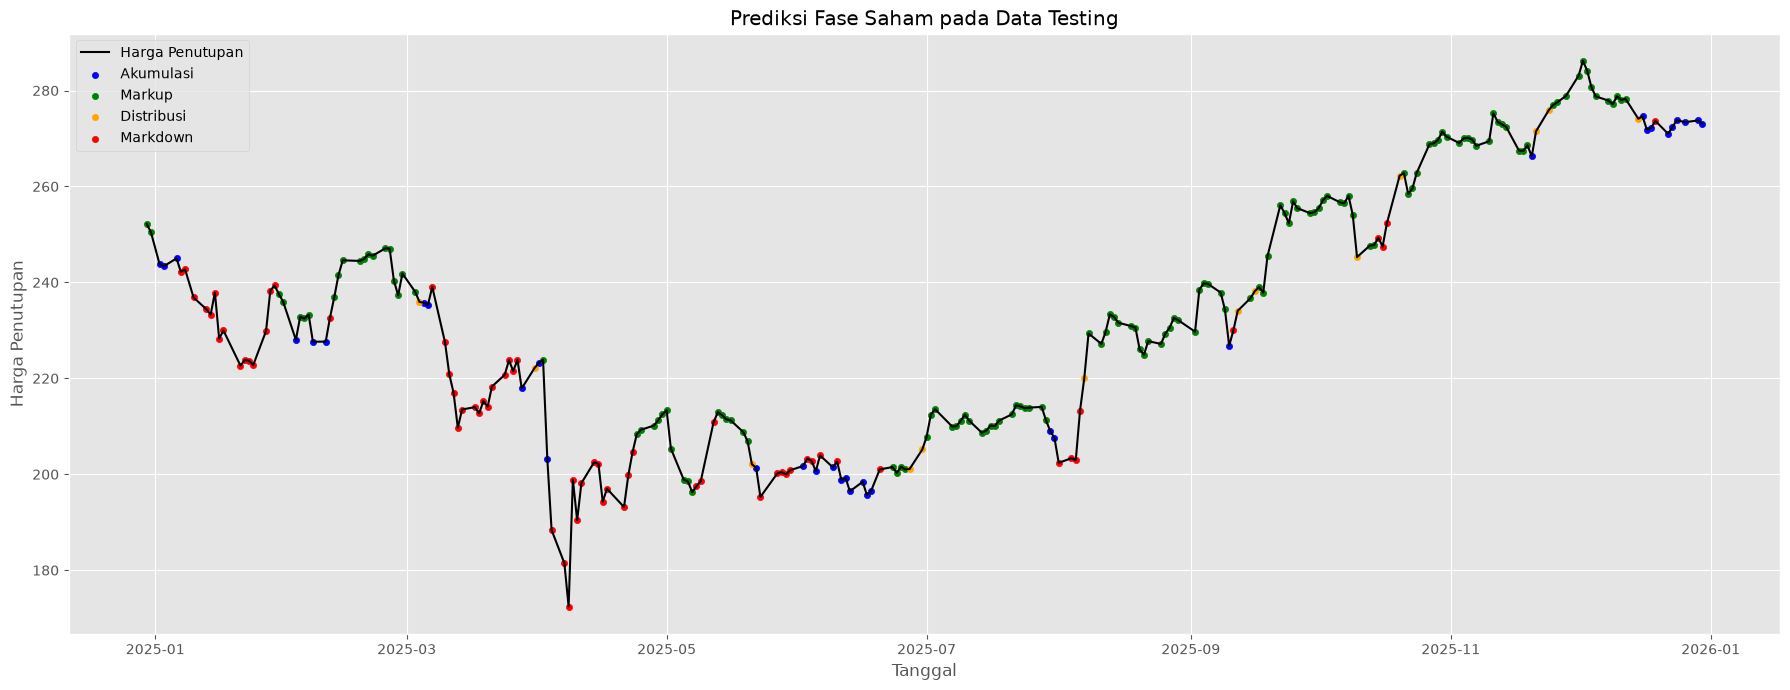

Price,Date,Close,Actual,Prediction,PredictionStatus
0,2024-12-30,252.2000,Markup,Markup,Benar
1,2024-12-31,250.4200,Markup,Markup,Benar
2,2025-01-02,243.8500,Markup,Akumulasi,Salah
3,2025-01-03,243.3600,Markup,Akumulasi,Salah
4,2025-01-06,245.0000,Markup,Akumulasi,Salah
5,2025-01-07,242.2100,Markup,Markdown,Salah
6,2025-01-08,242.7000,Markup,Markdown,Salah
7,2025-01-10,236.8500,Markdown,Markdown,Benar
8,2025-01-13,234.4000,Markdown,Markdown,Benar
9,2025-01-14,233.2800,Markdown,Markdown,Benar


In [88]:
comparison = pd.DataFrame({
    "Aktual": y_test.value_counts(),
    "Prediksi": pd.Series(rf_prediction).value_counts()
}).fillna(0)

comparison = comparison.astype(int)

comparison

plt.figure(figsize=(10,6))

x = np.arange(len(comparison.index))

width = 0.35

plt.bar(
    x - width/2,
    comparison["Aktual"],
    width,
    label="Aktual"
)

plt.bar(
    x + width/2,
    comparison["Prediksi"],
    width,
    label="Prediksi"
)

plt.xticks(
    x,
    comparison.index,
    rotation=0
)

plt.ylabel("Jumlah Data")

plt.title("Perbandingan Label Aktual dan Prediksi")

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

label_map = {
    "Akumulasi":0,
    "Markup":1,
    "Distribusi":2,
    "Markdown":3
}

actual = rf_prediction_df["Actual"].map(label_map)

prediction = rf_prediction_df["Prediction"].map(label_map)

plt.figure(figsize=(18,5))

plt.plot(
    rf_prediction_df["Date"],
    actual,
    linewidth=2,
    label="Aktual"
)

plt.plot(
    rf_prediction_df["Date"],
    prediction,
    linestyle="--",
    linewidth=2,
    label="Prediksi"
)

plt.yticks(
    [0,1,2,3],
    [
        "Akumulasi",
        "Markup",
        "Distribusi",
        "Markdown"
    ]
)

plt.xlabel("Tanggal")

plt.ylabel("Fase")

plt.title("Timeline Label Aktual dan Prediksi")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

plt.figure(figsize=(18,7))

plt.plot(
    rf_prediction_df["Date"],
    rf_prediction_df["Close"],
    color="black",
    linewidth=1.5,
    label="Harga Penutupan"
)

phase_color = {
    "Akumulasi":"blue",
    "Markup":"green",
    "Distribusi":"orange",
    "Markdown":"red"
}

for phase, color in phase_color.items():

    idx = rf_prediction_df["Prediction"] == phase

    plt.scatter(
        rf_prediction_df.loc[idx,"Date"],
        rf_prediction_df.loc[idx,"Close"],
        color=color,
        s=20,
        label=phase
    )

plt.title("Prediksi Fase Saham pada Data Testing")

plt.xlabel("Tanggal")

plt.ylabel("Harga Penutupan")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

rf_prediction_df[
    [
        "Date",
        "Close",
        "Actual",
        "Prediction",
        "PredictionStatus"
    ]
].head(20)

In [89]:
rf_summary = pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy":[rf_accuracy],
    "Precision":[rf_precision],
    "Recall":[rf_recall],
    "Macro F1":[rf_f1]
})

display(rf_summary)

,Model,Accuracy,Precision,Recall,Macro F1
0,Random Forest,0.5060,0.4761,0.4336,0.4100


## 9. Support Vector Machine

Pada tahap ini dilakukan pelatihan model Support Vector Machine (SVM) menggunakan fitur hasil Feature Engineering. Sebelum proses pelatihan, seluruh fitur dinormalisasi menggunakan StandardScaler agar memiliki skala yang seragam. Optimasi parameter dilakukan menggunakan GridSearchCV dengan lima-fold cross validation. Model terbaik dipilih berdasarkan nilai Macro F1-Score.

In [90]:
# ==========================================================
# STANDARD SCALER
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [91]:
# ==========================================================
# DATASET SETELAH STANDARDISASI
# ==========================================================

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns
)

display(
    X_train_scaled_df.head(10)
)

,Return,RVOL,TrendDiff,PricePosition,Breakout,Breakdown
0,-0.0489,0.0064,-0.1640,-0.6042,-0.3545,-0.2217
1,0.6894,-0.5546,-0.1640,0.1455,-0.3545,-0.2217
2,-2.0589,0.5239,-0.1640,-1.7481,-0.3545,4.5100
3,1.9887,-0.3880,-0.1640,0.1695,-0.3545,-0.2217
4,0.4665,-0.4058,-0.1640,0.6711,-0.3545,-0.2217
5,-1.4371,-0.4471,-0.1431,-0.6916,-0.3545,-0.2217
6,-0.1322,-0.5817,-0.2167,-0.7715,-0.3545,-0.2217
7,0.9201,-0.6004,-0.0405,0.1562,-0.3545,-0.2217
8,-0.9522,-0.5064,-0.1151,-0.7227,-0.3545,-0.2217
9,-0.8688,0.0670,-0.2956,-1.5084,-0.3545,-0.2217


In [92]:
# ==========================================================
# PARAMETER GRID
# ==========================================================

svm_param_grid = {

    "C":[
        0.1,
        1,
        10
    ],

    "gamma":[
        "scale",
        0.1,
        0.01
    ],

    "kernel":[
        "rbf"
    ]

}

In [93]:
# ==========================================================
# GRID SEARCH
# ==========================================================

svm_grid = GridSearchCV(

    estimator=SVC(),

    param_grid=svm_param_grid,

    cv=5,

    scoring="f1_macro",

    n_jobs=-1


)

svm_grid.fit(

    X_train_scaled,

    y_train

)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.1, ...], 'kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed du

In [94]:
# ==========================================================
# BEST PARAMETER
# ==========================================================

print("="*60)

print("BEST PARAMETER SVM")

print("="*60)

print(svm_grid.best_params_)

print()

print("Best Score :",svm_grid.best_score_)

BEST PARAMETER SVM
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Score : 0.4244102073214838


In [95]:
svm_model = svm_grid.best_estimator_

In [96]:
svm_prediction = svm_model.predict(
    X_test_scaled
)

In [97]:
svm_accuracy = accuracy_score(
    y_test,
    svm_prediction
)

svm_precision = precision_score(
    y_test,
    svm_prediction,
    average="macro"
)

svm_recall = recall_score(
    y_test,
    svm_prediction,
    average="macro"
)

svm_f1 = f1_score(
    y_test,
    svm_prediction,
    average="macro"
)

In [98]:
svm_result = pd.DataFrame({

    "Metrik":[
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1"
    ],

    "Nilai":[

        svm_accuracy,

        svm_precision,

        svm_recall,

        svm_f1

    ]

})

display(
    svm_result
)

,Metrik,Nilai
0,Accuracy,0.4741
1,Precision,0.4489
2,Recall,0.4108
3,Macro F1,0.3874


In [99]:
report = classification_report(

    y_test,

    svm_prediction,

    output_dict=True

)

svm_report = pd.DataFrame(
    report
).transpose()

display(
    svm_report
)

,precision,recall,f1-score,support
Akumulasi,0.1842,0.2188,0.2000,32.0000
Distribusi,0.4000,0.1111,0.1739,54.0000
Markdown,0.7759,0.5000,0.6081,90.0000
Markup,0.4357,0.8133,0.5674,75.0000
accuracy,0.4741,0.4741,0.4741,0.4741
macro avg,0.4489,0.4108,0.3874,251.0000
weighted avg,0.5179,0.4741,0.4505,251.0000


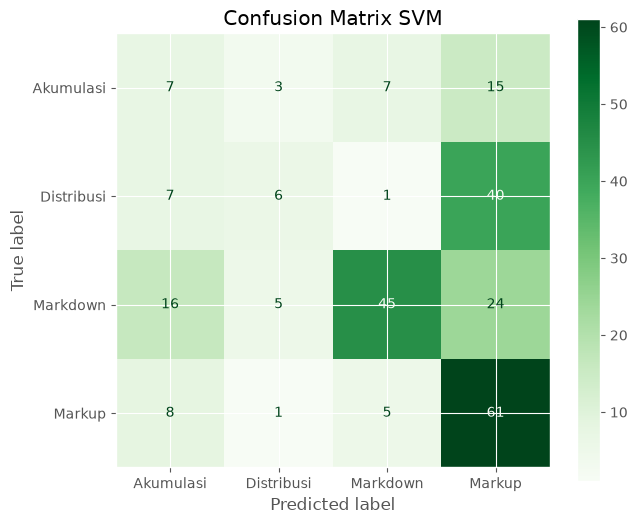

In [100]:
cm = confusion_matrix(
    y_test,
    svm_prediction,
    labels=svm_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Greens",
    ax=ax
)

plt.title(
    "Confusion Matrix SVM"
)

plt.show()

In [101]:
svm_prediction_df = test_data.copy()

svm_prediction_df["Actual"] = y_test.values

svm_prediction_df["Prediction"] = svm_prediction

In [102]:
svm_prediction_df["PredictionStatus"] = np.where(

    svm_prediction_df["Actual"]

    ==

    svm_prediction_df["Prediction"],

    "Benar",

    "Salah"

)

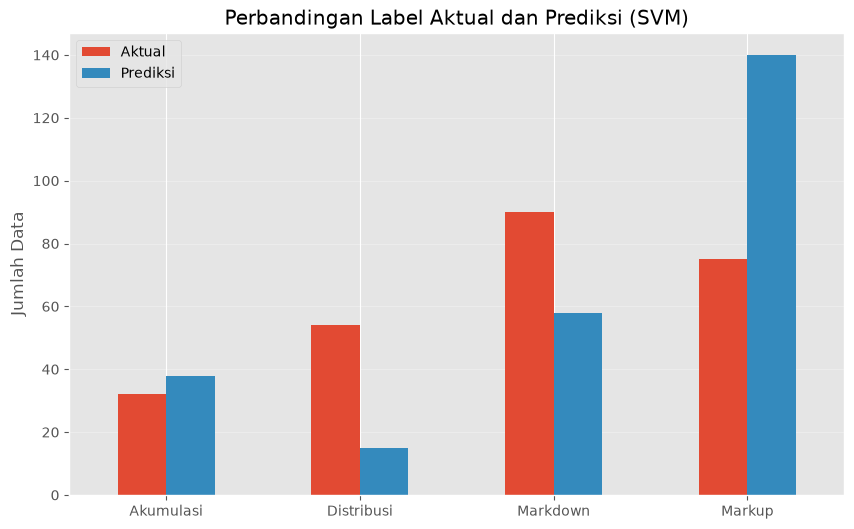

In [103]:
comparison = pd.DataFrame({
    "Aktual": y_test.value_counts(),
    "Prediksi": pd.Series(svm_prediction).value_counts()
}).fillna(0).astype(int)

comparison

comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Perbandingan Label Aktual dan Prediksi (SVM)"
)

plt.ylabel("Jumlah Data")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.show()

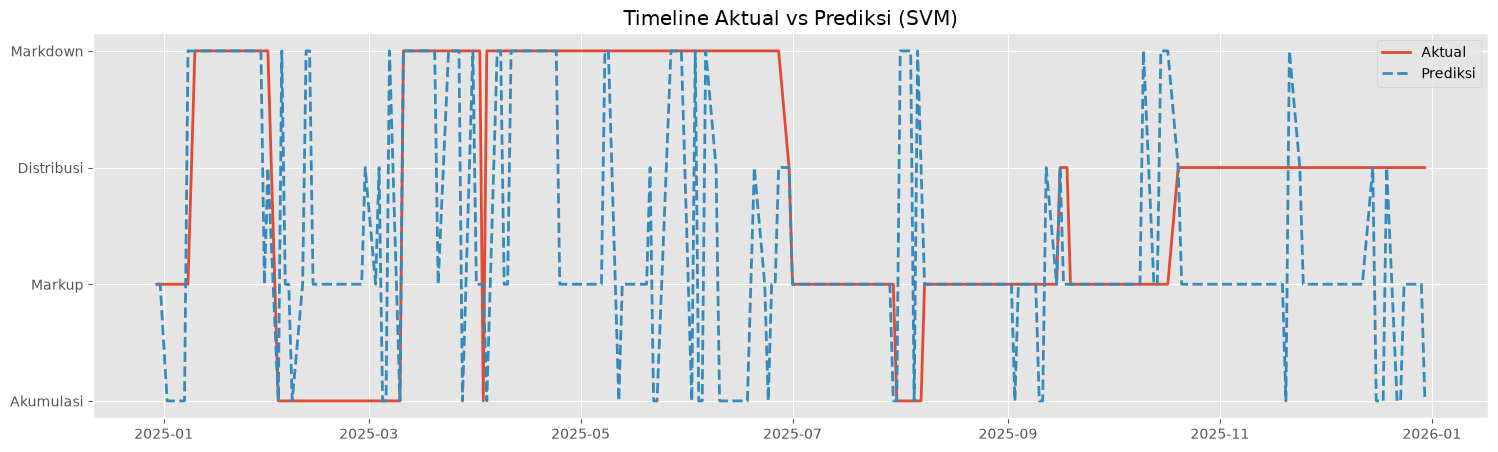

In [104]:
label_map = {

    "Akumulasi":0,

    "Markup":1,

    "Distribusi":2,

    "Markdown":3

}

actual = svm_prediction_df["Actual"].map(label_map)

prediction = svm_prediction_df["Prediction"].map(label_map)

plt.figure(figsize=(18,5))

plt.plot(
    svm_prediction_df["Date"],
    actual,
    linewidth=2,
    label="Aktual"
)

plt.plot(
    svm_prediction_df["Date"],
    prediction,
    linestyle="--",
    linewidth=2,
    label="Prediksi"
)

plt.yticks(
    [0,1,2,3],
    [
        "Akumulasi",
        "Markup",
        "Distribusi",
        "Markdown"
    ]
)

plt.title(
    "Timeline Aktual vs Prediksi (SVM)"
)

plt.legend()

plt.grid(True)

plt.show()

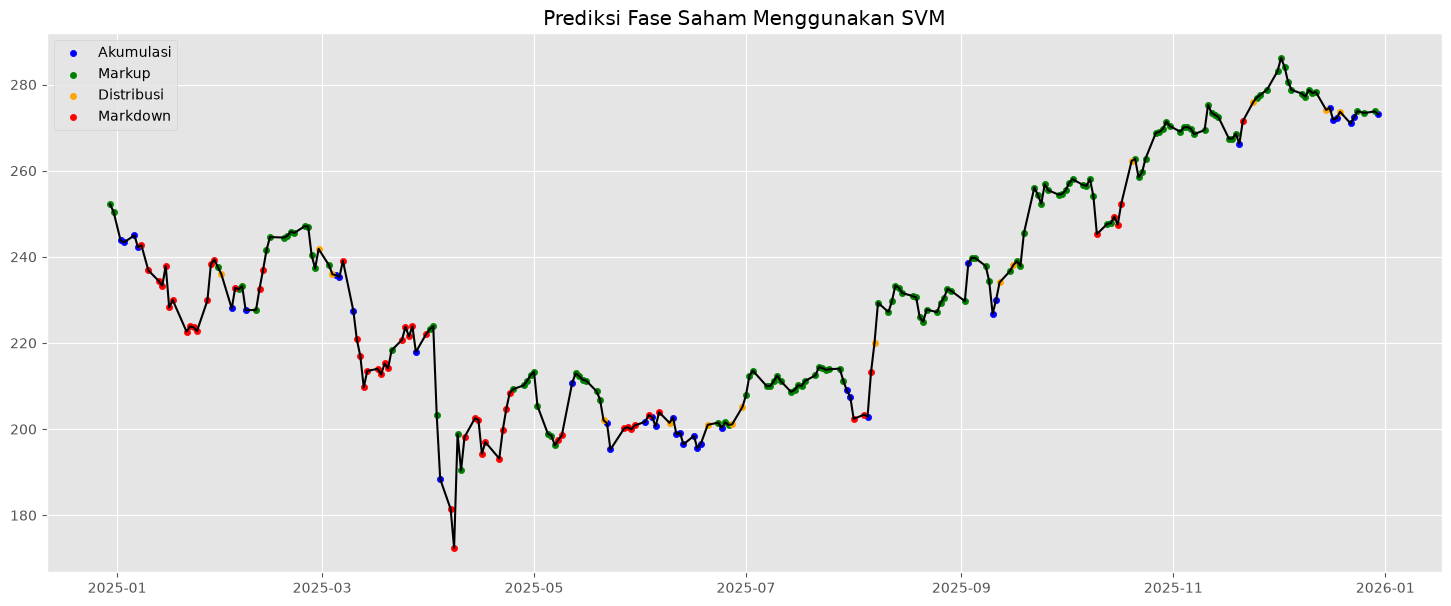

In [105]:
plt.figure(figsize=(18,7))

plt.plot(
    svm_prediction_df["Date"],
    svm_prediction_df["Close"],
    color="black",
    linewidth=1.5
)

phase_color = {

    "Akumulasi":"blue",

    "Markup":"green",

    "Distribusi":"orange",

    "Markdown":"red"

}

for phase, color in phase_color.items():

    idx = svm_prediction_df["Prediction"] == phase

    plt.scatter(
        svm_prediction_df.loc[idx,"Date"],
        svm_prediction_df.loc[idx,"Close"],
        color=color,
        s=20,
        label=phase
    )

plt.title(
    "Prediksi Fase Saham Menggunakan SVM"
)

plt.legend()

plt.grid(True)

plt.show()

In [106]:
svm_summary = pd.DataFrame({
    "Model":["Support Vector Machine"],
    "Accuracy":[svm_accuracy],
    "Precision":[svm_precision],
    "Recall":[svm_recall],
    "Macro F1":[svm_f1]
})

display(svm_summary)

,Model,Accuracy,Precision,Recall,Macro F1
0,Support Vector Machine,0.4741,0.4489,0.4108,0.3874


# 10. Evaluasi dan Perbandingan Model

Tahap evaluasi bertujuan untuk membandingkan performa model Random Forest dan Support Vector Machine dalam mengklasifikasikan empat fase utama saham.

Evaluasi dilakukan menggunakan empat metrik utama, yaitu:

- Accuracy
- Precision
- Recall
- Macro F1-Score

Macro F1-Score dipilih sebagai metrik utama karena mampu mengevaluasi performa klasifikasi multikelas secara seimbang tanpa dipengaruhi oleh jumlah data pada masing-masing kelas.

In [107]:
# ==========================================================
# RINGKASAN HASIL MODEL
# ==========================================================

comparison_result = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Support Vector Machine"

    ],

    "Accuracy":[

        rf_accuracy,

        svm_accuracy

    ],

    "Precision":[

        rf_precision,

        svm_precision

    ],

    "Recall":[

        rf_recall,

        svm_recall

    ],

    "Macro F1":[

        rf_f1,

        svm_f1

    ]

})

comparison_result

,Model,Accuracy,Precision,Recall,Macro F1
0,Random Forest,0.5060,0.4761,0.4336,0.4100
1,Support Vector Machine,0.4741,0.4489,0.4108,0.3874


In [108]:
# ==========================================================
# MODEL TERBAIK
# ==========================================================

best_model = comparison_result.loc[
    comparison_result["Macro F1"].idxmax()
]

print("="*60)

print("MODEL TERBAIK")

print("="*60)

display(best_model)

MODEL TERBAIK


Model        Random Forest
Accuracy            0.5060
Precision           0.4761
Recall              0.4336
Macro F1            0.4100
Name: 0, dtype: object

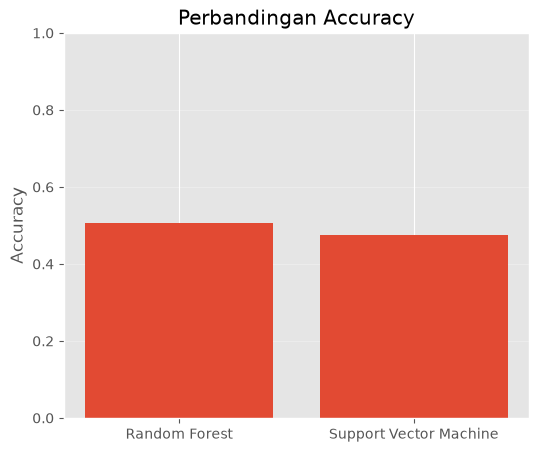

In [109]:
plt.figure(figsize=(6,5))

plt.bar(

    comparison_result["Model"],

    comparison_result["Accuracy"]

)

plt.title("Perbandingan Accuracy")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

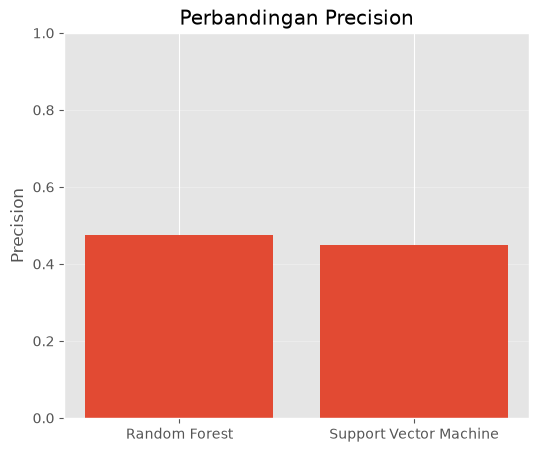

In [110]:
plt.figure(figsize=(6,5))

plt.bar(

    comparison_result["Model"],

    comparison_result["Precision"]

)

plt.title("Perbandingan Precision")

plt.ylabel("Precision")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

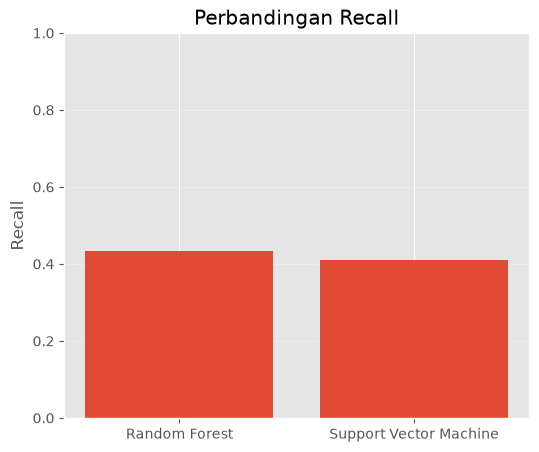

In [111]:
plt.figure(figsize=(6,5))

plt.bar(

    comparison_result["Model"],

    comparison_result["Recall"]

)

plt.title("Perbandingan Recall")

plt.ylabel("Recall")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

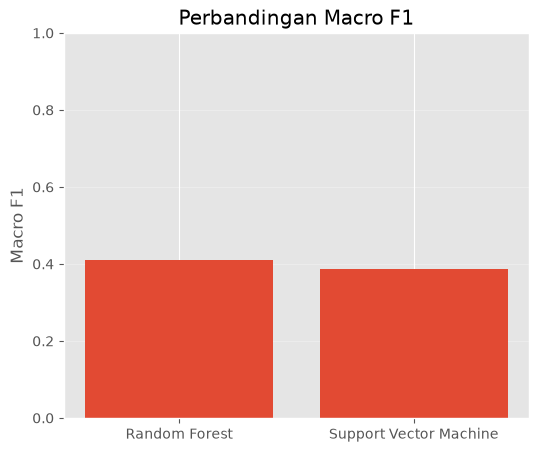

In [112]:
plt.figure(figsize=(6,5))

plt.bar(

    comparison_result["Model"],

    comparison_result["Macro F1"]

)

plt.title("Perbandingan Macro F1")

plt.ylabel("Macro F1")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

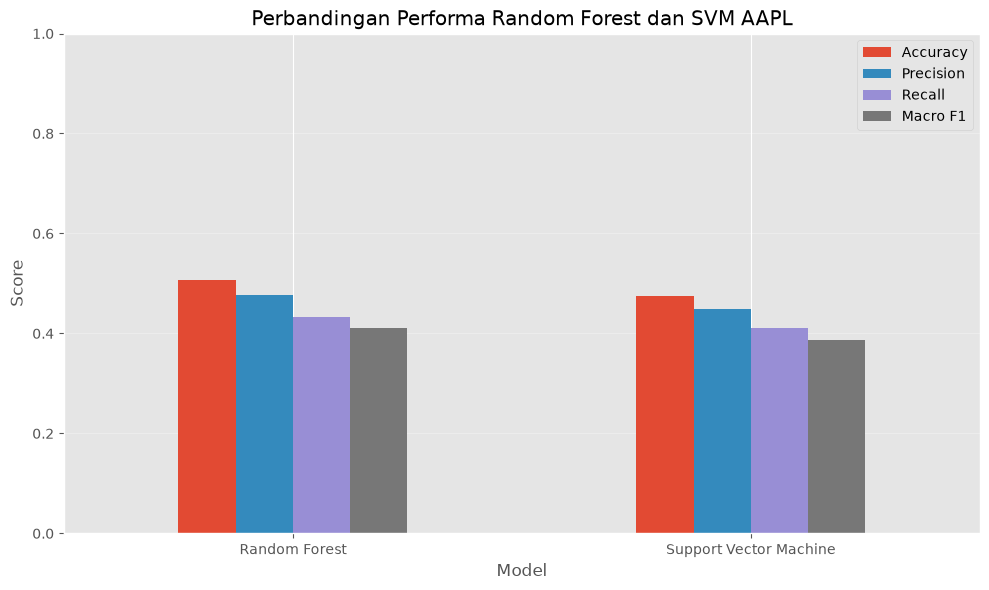

In [113]:
# ==========================================================
# PERBANDINGAN METRIK
# ==========================================================

metric = comparison_result.set_index("Model")

metric.plot(

    kind="bar",

    figsize=(10,6)

)

plt.title(

    "Perbandingan Performa Random Forest dan SVM "+TICKER

)

plt.ylabel("Score")

plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [114]:
print("="*60)

print("Random Forest")

display(rf_report)

print("="*60)

print("Support Vector Machine")

display(svm_report)

Random Forest


,precision,recall,f1-score,support
Akumulasi,0.2059,0.2188,0.2121,32.0000
Distribusi,0.4615,0.1111,0.1791,54.0000
Markdown,0.7879,0.5778,0.6667,90.0000
Markup,0.4493,0.8267,0.5822,75.0000
accuracy,0.5060,0.5060,0.5060,0.5060
macro avg,0.4761,0.4336,0.4100,251.0000
weighted avg,0.5423,0.5060,0.4786,251.0000


Support Vector Machine


,precision,recall,f1-score,support
Akumulasi,0.1842,0.2188,0.2000,32.0000
Distribusi,0.4000,0.1111,0.1739,54.0000
Markdown,0.7759,0.5000,0.6081,90.0000
Markup,0.4357,0.8133,0.5674,75.0000
accuracy,0.4741,0.4741,0.4741,0.4741
macro avg,0.4489,0.4108,0.3874,251.0000
weighted avg,0.5179,0.4741,0.4505,251.0000


In [115]:
rf_correct = (
    rf_prediction_df["PredictionStatus"]
    == "Benar"
).sum()

svm_correct = (
    svm_prediction_df["PredictionStatus"]
    == "Benar"
).sum()

correct = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Support Vector Machine"

    ],

    "Prediksi Benar":[

        rf_correct,

        svm_correct

    ]

})

correct



,Model,Prediksi Benar
0,Random Forest,127
1,Support Vector Machine,119


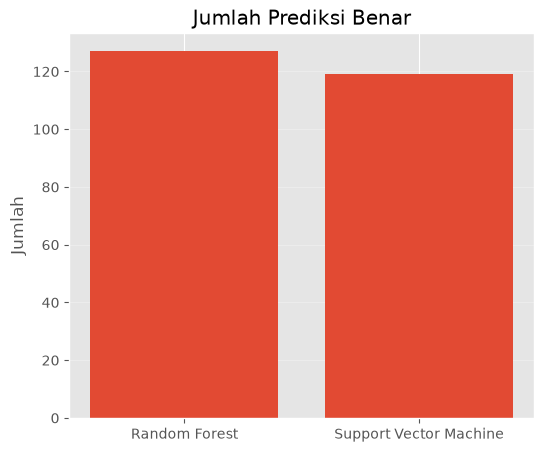

In [116]:
plt.figure(figsize=(6,5))

plt.bar(

    correct["Model"],

    correct["Prediksi Benar"]

)

plt.title("Jumlah Prediksi Benar")

plt.ylabel("Jumlah")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [117]:
rf_wrong = (
    rf_prediction_df["PredictionStatus"]
    == "Salah"
).sum()

svm_wrong = (
    svm_prediction_df["PredictionStatus"]
    == "Salah"
).sum()

wrong = pd.DataFrame({

    "Model":[

        "Random Forest",

        "Support Vector Machine"

    ],

    "Prediksi Salah":[

        rf_wrong,

        svm_wrong

    ]

})

wrong

,Model,Prediksi Salah
0,Random Forest,124
1,Support Vector Machine,132


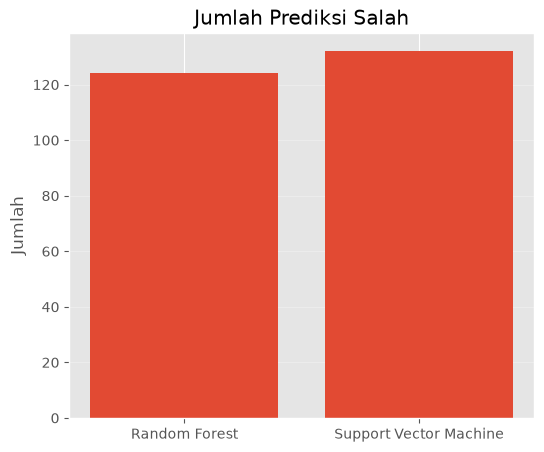

In [118]:
plt.figure(figsize=(6,5))

plt.bar(

    wrong["Model"],

    wrong["Prediksi Salah"]

)

plt.title("Jumlah Prediksi Salah")

plt.ylabel("Jumlah")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [119]:
comparison_result.to_csv(

    "model_comparison.csv",

    index=False

)

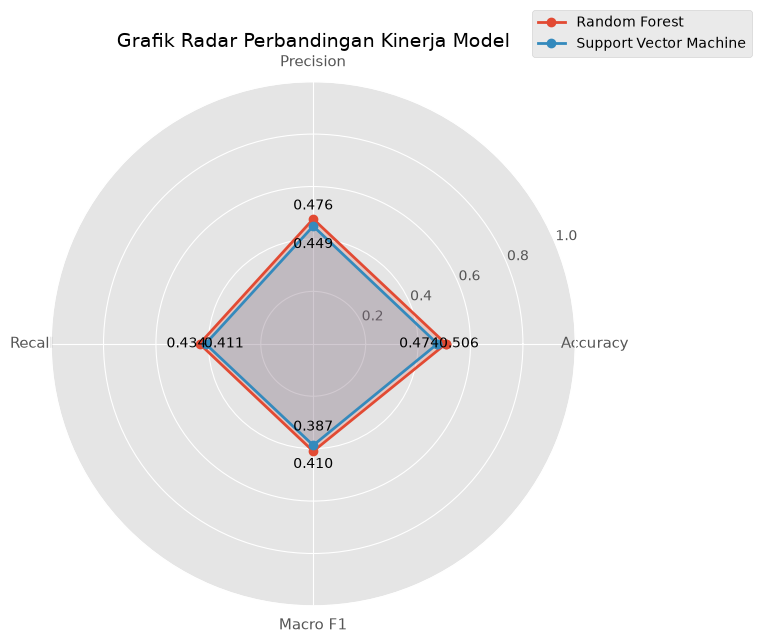

In [120]:
# ==========================================================
# GRAFIK RADAR — VERSI AMAN
# ==========================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "Macro F1"
]

rf_values = np.array([
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1
], dtype=float)

svm_values = np.array([
    svm_accuracy,
    svm_precision,
    svm_recall,
    svm_f1
], dtype=float)

angles = np.linspace(
    0,
    2 * np.pi,
    len(metrics),
    endpoint=False
)

# Menutup poligon
angles_closed = np.concatenate([
    angles,
    angles[:1]
])

rf_closed = np.concatenate([
    rf_values,
    rf_values[:1]
])

svm_closed = np.concatenate([
    svm_values,
    svm_values[:1]
])

fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"polar": True}
)

ax.plot(
    angles_closed,
    rf_closed,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

ax.fill(
    angles_closed,
    rf_closed,
    alpha=0.20
)

ax.plot(
    angles_closed,
    svm_closed,
    marker="o",
    linewidth=2,
    label="Support Vector Machine"
)

ax.fill(
    angles_closed,
    svm_closed,
    alpha=0.20
)

ax.set_xticks(angles)
ax.set_xticklabels(metrics, fontsize=11)

ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0.2, 1.01, 0.2))
ax.set_yticklabels([
    "0.2",
    "0.4",
    "0.6",
    "0.8",
    "1.0"
])

ax.set_title(
    "Grafik Radar Perbandingan Kinerja Model",
    fontsize=14,
    pad=25
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.35, 1.15)
)

for angle, value in zip(angles, rf_values):
    ax.text(
        angle,
        min(value + 0.05, 1),
        f"{value:.3f}",
        ha="center",
        va="center"
    )

for angle, value in zip(angles, svm_values):
    ax.text(
        angle,
        max(value - 0.07, 0),
        f"{value:.3f}",
        ha="center",
        va="center"
    )

plt.tight_layout()
plt.show()

In [121]:
print("="*60)

print("KESIMPULAN")

print("="*60)

print(

    f"Model terbaik adalah "

    f"{best_model['Model']}"

)

print()

print(

    f"Macro F1 = "

    f"{best_model['Macro F1']:.4f}"

)

KESIMPULAN
Model terbaik adalah Random Forest

Macro F1 = 0.4100


## 11. Ekspor Hasil Akhir

Tahap ini menyimpan seluruh hasil penelitian, meliputi dataset berlabel, hasil prediksi, metrik evaluasi, classification report, confusion matrix, model terlatih, scaler, dan parameter terbaik.

Seluruh file disimpan ke dalam folder `outputs` agar hasil eksperimen terorganisasi dan mudah digunakan pada penyusunan laporan maupun artikel jurnal.

In [122]:
# ==========================================================
# 11.1 MEMBUAT FOLDER OUTPUT
# ==========================================================

from pathlib import Path

SAFE_TICKER = TICKER.replace(".", "_")

OUTPUT_DIR = Path("outputs") / SAFE_TICKER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output disimpan di:", OUTPUT_DIR.resolve())

Output disimpan di: C:\Users\Muhamad Rafiansyah\OneDrive\Documents\TA_Rafi_4\outputs\AAPL


In [123]:
# ==========================================================
# 11.2 MENYIMPAN DATASET
# ==========================================================

df.to_csv(
    OUTPUT_DIR / "dataset_awal.csv",
    index=False
)

df_clean.to_csv(
    OUTPUT_DIR / "dataset_cleaned.csv",
    index=False
)

df_feature.to_csv(
    OUTPUT_DIR / "dataset_feature_engineered.csv",
    index=False
)

df_label.to_csv(
    OUTPUT_DIR / "dataset_labeled.csv",
    index=False
)

train_data.to_csv(
    OUTPUT_DIR / "dataset_training.csv",
    index=False
)

test_data.to_csv(
    OUTPUT_DIR / "dataset_testing.csv",
    index=False
)

print("Seluruh dataset berhasil disimpan.")

Seluruh dataset berhasil disimpan.


In [124]:
# ==========================================================
# 11.3 DISTRIBUSI LABEL
# ==========================================================

label_summary = (
    df_label["Label"]
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Jumlah")
)

label_summary["Persentase"] = (
    label_summary["Jumlah"]
    / label_summary["Jumlah"].sum()
    * 100
)

label_summary.to_csv(
    OUTPUT_DIR / "label_summary.csv",
    index=False
)

display(label_summary)

,Label,Jumlah,Persentase
0,Markdown,420,33.4928
1,Markup,409,32.6156
2,Distribusi,219,17.4641
3,Akumulasi,206,16.4274


In [125]:
# ==========================================================
# 11.4 DATASET HASIL PREDIKSI
# ==========================================================

rf_prediction_df.to_csv(
    OUTPUT_DIR / "rf_test_predictions.csv",
    index=False
)

svm_prediction_df.to_csv(
    OUTPUT_DIR / "svm_test_predictions.csv",
    index=False
)

print("Dataset hasil prediksi berhasil disimpan.")

Dataset hasil prediksi berhasil disimpan.


In [126]:
# ==========================================================
# 11.5 DATASET STANDARDISASI SVM
# ==========================================================

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns
)

X_train_scaled_df["Label"] = y_train.reset_index(drop=True)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns
)

X_test_scaled_df["Label"] = y_test.reset_index(drop=True)

X_train_scaled_df.to_csv(
    OUTPUT_DIR / "svm_train_standardized.csv",
    index=False
)

X_test_scaled_df.to_csv(
    OUTPUT_DIR / "svm_test_standardized.csv",
    index=False
)

print("Data hasil standardisasi SVM berhasil disimpan.")

Data hasil standardisasi SVM berhasil disimpan.


In [127]:
# ==========================================================
# 11.6 CLASSIFICATION REPORT
# ==========================================================

rf_report.to_csv(
    OUTPUT_DIR / "rf_classification_report.csv"
)

svm_report.to_csv(
    OUTPUT_DIR / "svm_classification_report.csv"
)

print("Classification report berhasil disimpan.")

Classification report berhasil disimpan.


In [128]:
# ==========================================================
# 11.7 CONFUSION MATRIX
# ==========================================================

rf_labels = list(rf_model.classes_)
svm_labels = list(svm_model.classes_)

rf_cm = pd.DataFrame(
    confusion_matrix(
        y_test,
        rf_prediction,
        labels=rf_labels
    ),
    index=[f"Aktual_{label}" for label in rf_labels],
    columns=[f"Prediksi_{label}" for label in rf_labels]
)

svm_cm = pd.DataFrame(
    confusion_matrix(
        y_test,
        svm_prediction,
        labels=svm_labels
    ),
    index=[f"Aktual_{label}" for label in svm_labels],
    columns=[f"Prediksi_{label}" for label in svm_labels]
)

rf_cm.to_csv(
    OUTPUT_DIR / "rf_confusion_matrix.csv"
)

svm_cm.to_csv(
    OUTPUT_DIR / "svm_confusion_matrix.csv"
)

print("Confusion matrix berhasil disimpan.")

Confusion matrix berhasil disimpan.


In [129]:
# ==========================================================
# 11.8 PERBANDINGAN MODEL
# ==========================================================

comparison_result.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)

display(comparison_result)

,Model,Accuracy,Precision,Recall,Macro F1
0,Random Forest,0.5060,0.4761,0.4336,0.4100
1,Support Vector Machine,0.4741,0.4489,0.4108,0.3874


In [130]:
# ==========================================================
# 11.9 METRICS.JSON
# ==========================================================

import json

metrics_output = {
    "Random Forest": {
        "metrics": {
            "accuracy": float(rf_accuracy),
            "precision_macro": float(rf_precision),
            "recall_macro": float(rf_recall),
            "f1_macro": float(rf_f1)
        },
        "best_params": rf_grid.best_params_
    },
    "Support Vector Machine": {
        "metrics": {
            "accuracy": float(svm_accuracy),
            "precision_macro": float(svm_precision),
            "recall_macro": float(svm_recall),
            "f1_macro": float(svm_f1)
        },
        "best_params": svm_grid.best_params_
    },
    "best_model": str(best_model["Model"]),
    "selection_metric": "Macro F1"
}

with open(
    OUTPUT_DIR / "metrics.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metrics_output,
        file,
        indent=4,
        ensure_ascii=False
    )

print("metrics.json berhasil disimpan.")

metrics.json berhasil disimpan.


In [131]:
# ==========================================================
# 11.10 METADATA PENELITIAN
# ==========================================================

metadata = {
    "ticker": TICKER,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "rows_raw": int(len(df)),
    "rows_cleaned": int(len(df_clean)),
    "rows_feature_engineered": int(len(df_feature)),
    "rows_labeled": int(len(df_label)),
    "rows_training": int(len(train_data)),
    "rows_testing": int(len(test_data)),
    "test_size": float(TEST_SIZE),
    "random_state": int(RANDOM_STATE),
    "features": feature_columns,
    "target": target_column,
    "thresholds": {
        "trend_threshold": float(TREND_THRESHOLD),
        "rvol_high": float(RVOL_HIGH),
        "return_positive": float(RETURN_POSITIVE),
        "return_negative": float(RETURN_NEGATIVE),
        "low_position": float(LOW_POSITION),
        "high_position": float(HIGH_POSITION)
    },
    "best_model": str(best_model["Model"])
}

with open(
    OUTPUT_DIR / "metadata.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metadata,
        file,
        indent=4,
        ensure_ascii=False
    )

print("metadata.json berhasil disimpan.")

metadata.json berhasil disimpan.


In [132]:
# ==========================================================
# 11.11 SIMPAN MODEL
# ==========================================================

joblib.dump(
    rf_model,
    OUTPUT_DIR / "random_forest_model.joblib"
)

joblib.dump(
    svm_model,
    OUTPUT_DIR / "svm_model.joblib"
)

joblib.dump(
    scaler,
    OUTPUT_DIR / "standard_scaler.joblib"
)

print("Model dan scaler berhasil disimpan.")

Model dan scaler berhasil disimpan.


In [133]:
# ==========================================================
# 11.12 FEATURE IMPORTANCE RANDOM FOREST
# ==========================================================

rf_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_feature_importance.to_csv(
    OUTPUT_DIR / "rf_feature_importance.csv",
    index=False
)

display(rf_feature_importance)

,Feature,Importance
2,TrendDiff,0.4647
3,PricePosition,0.2526
1,RVOL,0.1357
0,Return,0.1065
5,Breakdown,0.0236
4,Breakout,0.0169


In [134]:
# ==========================================================
# 11.13 MEMBUAT ZIP HASIL
# ==========================================================

import shutil

zip_path = shutil.make_archive(
    base_name="hasil_eksperimen_klasifikasi_fase_saham",
    format="zip",
    root_dir=OUTPUT_DIR
)

print(f"ZIP hasil berhasil dibuat: {zip_path}")

ZIP hasil berhasil dibuat: c:\Users\Muhamad Rafiansyah\OneDrive\Documents\TA_Rafi_4\hasil_eksperimen_klasifikasi_fase_saham.zip


In [135]:
# ==========================================================
# 11.14 DAFTAR OUTPUT
# ==========================================================

output_files = sorted(
    file.name
    for file in OUTPUT_DIR.iterdir()
    if file.is_file()
)

print("=" * 60)
print("DAFTAR FILE OUTPUT")
print("=" * 60)

for file_name in output_files:
    print("-", file_name)

DAFTAR FILE OUTPUT
- dataset_awal.csv
- dataset_cleaned.csv
- dataset_feature_engineered.csv
- dataset_labeled.csv
- dataset_testing.csv
- dataset_training.csv
- label_summary.csv
- metadata.json
- metrics.json
- model_comparison.csv
- random_forest_model.joblib
- rf_classification_report.csv
- rf_confusion_matrix.csv
- rf_feature_importance.csv
- rf_test_predictions.csv
- standard_scaler.joblib
- svm_classification_report.csv
- svm_confusion_matrix.csv
- svm_model.joblib
- svm_test_predictions.csv
- svm_test_standardized.csv
- svm_train_standardized.csv
